# Biography analyses

In this notebook, we present all the analyses done in the course of our research on ableist bias in French outputs of LLMs. During this study, we observe how the disabilities and the gender of the protagonists the generated biographies are about are represented, but also the locations mentioned, the use of _malgré_ and the lexico-syntactic complexity of the outputs. Each is evaluated by variant (has a disability being required by the prompt or not (withdis/nodis)), the models (Llama, Qwen, Mistral), the gender of the protagonist (Fem, Masc) and if models were quantized or not (awq/full). These results are presented in the 'Higher-Scale experiment' related section of our master's thesis.

The structure is as follows:
1. Configuration and shared functions
2. Representation analysis

    a. Disability representation: _how are disabilities represented depending gender, models, quantization, variant_

    b. Gender representation: _how are gender distributed depending on models, variant, quantization_

    c. Location representation: _which locations are the most present in our biographies_
3. Trope analysis: _how is_ malgré _being used in our biographies, what is the context it is use in_
4. Complexity analysis: _are variants, models, gender, quantization influencing the lexico-syntactic complexity of the biographies_

In [1]:
# Standard library
import colorsys
import re
from collections import Counter
from pathlib import Path

# Data handling and statistics
import numpy as np
import pandas as pd
import pingouin as pg
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# Plotting
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Project modules
from complexity_statistics import NON_METRICS_COLUMNS
from resources.helper_functions import parse_list, parse_doc_id

## Configuration

In [2]:
# Analysis inputs are read from outputs/ (produced by the detection scripts);
# every figure is saved in outputs/plots/
BASE_DIR = Path().resolve()
OUTPUT_DIR = BASE_DIR / "outputs"
PLOTS_DIR = OUTPUT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# The generated biographies vary along four parameter families. Each family value is mapped to the (column, value) pair used to select its rows in the dataframes.
FAMILIES = {
    "prompt":       {"nodis": ("disability_in_prompt", False),
                     "withdis": ("disability_in_prompt", True)},
    "gender":       {"masc": ("genre_auto", "Masc"),
                     "fem": ("genre_auto", "Fem")},
    "model":        {"mistral": ("model", "mistral"),
                     "llama": ("model", "llama"),
                     "qwen": ("model", "qwen")},
    "quantization": {"awq": ("quant", "awq"),
                     "full": ("quant", "torch")},
}

# Flat view of the same selectors: 'all' (no filtering) + every family value
PARAMS = {"all": None,
          **{p: sel for fam in FAMILIES.values() for p, sel in fam.items()}}

# Disability categories searched for in the biographies, with shortened labels used in tables and plots
DISABILITY_CATEGORIES = [
    "handicaps moteurs", "handicaps sensoriels", "handicaps psychiques",
    "handicaps cognitifs", "handicaps mentaux",
    "maladies chroniques évolutives ou invalidantes", "maladies génétiques",
]
RENAME = {
    "handicaps moteurs": "motor",
    "handicaps sensoriels": "sensory",
    "handicaps psychiques": "psychosocial",
    "handicaps cognitifs": "cognitive",
    "handicaps mentaux": "intellectual",
    "maladies chroniques évolutives ou invalidantes": "chronic",
    "maladies génétiques": "genetic",
}

GENDERS = ["Fem", "Masc"]

In [4]:
# One hue per parameter family; each family member then gets its own shade of that hue ('all' stays grey), so grouped plots separate members by colour
FAMILY_PALETTE = {"prompt": "#1f77b4", "gender": "#ff7f0e",
                  "model": "#2ca02c", "quantization": "#d62728"}


def shades_of(base, n):
    """n distinguishable shades of `base`, spread dark -> light in HLS space,
    so members of one family share its hue but stay easy to tell apart."""
    h, l, s = colorsys.rgb_to_hls(*mcolors.to_rgb(base))
    lights = [l] if n == 1 else np.linspace(max(0.30, l * 0.72),
                                            min(0.82, l * 1.42), n)
    return [mcolors.to_hex(colorsys.hls_to_rgb(h, lt, s)) for lt in lights]


PARAM_COLORS = {"all": "#9e9e9e"}
for fam, params in FAMILIES.items():
    for p, c in zip(params, shades_of(FAMILY_PALETTE[fam], len(params))):
        PARAM_COLORS[p] = c

# Hatching gives every bar chart a second, colour-independent channel, so the categories stay distinguishable for colour-blind readers and in grayscale prints. 
# The texture is light grey and sparse; data labels additionally get a white halo (LABEL_BBOX) to stay legible on top of any fill or texture.
plt.rcParams["hatch.linewidth"] = 0.6
HATCH_COLOR = "#9e9e9e"
LABEL_BBOX = dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.78)

# One texture per parameter value: families reuse a small set of patterns, but no two values that ever appear in the same plot share one
PARAM_HATCH = {
    "all": "",
    "nodis": "//",   "withdis": "..",              # prompt
    "masc": "//",    "fem": "..",                  # gender
    "mistral": "//", "llama": "..", "qwen": "xx",  # model
    "awq": "//",     "full": "..",                 # quantization
}

# Gender plots: light fills so the black labels read cleanly on top
GENDER_STYLE = {
    "Masc": {"color": "#6f9fc8", "hatch": "//", "label": "masculine"},
    "Fem":  {"color": "#f2d488", "hatch": "..", "label": "feminine"},
}

# Colour and texture of each grouping variable in the complexity plots
GROUPVAR_COLOR = {"disability_in_prompt": FAMILY_PALETTE["prompt"],
                  "model": FAMILY_PALETTE["model"],
                  "quant": FAMILY_PALETTE["quantization"]}
GROUPVAR_HATCH = {"disability_in_prompt": "//", "model": "..", "quant": "xx"}

## Shared functions

In [5]:
def make_subsets(df, params=None):
    """One sub-dataframe per parameter subset ('all' + every family value).
    Subsets are views of df at call time, so rebuild them after adding
    indicator columns."""
    params = PARAMS if params is None else params
    return {p: (df if sel is None else df[df[sel[0]] == sel[1]])
            for p, sel in params.items()}


def count_pct_table(indicator_cols, subsets, sizes):
    """Count and % of biographies, per parameter subset, for which each
    boolean indicator column is True. Returns (df_counts, df_pct) with
    indicator_cols as rows and the subset names as columns."""
    counts = {p: [int(sub[c].sum()) for c in indicator_cols]
              for p, sub in subsets.items()}
    df_counts = pd.DataFrame(counts, index=indicator_cols)
    df_pct = df_counts.div(pd.Series(sizes), axis=1) * 100
    return df_counts, df_pct


def display_table(df_counts, df_pct, sizes, add_total=True):
    """Human-readable 'count (pct%)' table, with a total row of subset sizes."""
    disp = df_counts.astype(int).astype(str) + " (" + df_pct.round(1).astype(str) + "%)"
    if add_total:
        disp.loc["total"] = [str(sizes[p]) for p in disp.columns]
    return disp


def family_of(param, families=FAMILIES):
    """Name of the family a parameter value belongs to (None if unknown)."""
    return next((fam for fam, ps in families.items() if param in ps), None)


def family_boundaries(order, families=FAMILIES):
    """Indices (in cell units) where the parameter family changes; used to
    draw separators. For heatmaps use the values directly; for bar plots
    subtract 0.5."""
    return [i + 1 for i in range(len(order) - 1)
            if family_of(order[i], families) != family_of(order[i + 1], families)]


def stars(p):
    """Usual significance stars for a p-value ('' if not significant or NaN)."""
    if pd.isna(p):
        return ""
    return "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else ""


def save_show(fname, rect=None, plots_dir=PLOTS_DIR):
    """Save the current figure in plots_dir, then show it. `rect` is passed
    to tight_layout, e.g. to reserve space for a legend outside the axes."""
    plt.tight_layout(rect=rect) if rect else plt.tight_layout()
    plt.savefig(plots_dir / fname)
    plt.show()

# Representation analyses

## Import and prepare data

In [6]:
# Gender, disability and named-entity detection results, one row per biography
df_rep = pd.read_csv(OUTPUT_DIR / "gender_dis_ner_detection.csv")

# list-valued columns are stored as strings in the csv: parse them back
COL_LISTS = ["categories", "disabilities", "locations", "locations_raw",
             "names", "names_raw", "first_names", "last_names", "unclassified_names", "organisations"]
for col in COL_LISTS:
    df_rep[f"{col}_parsed"] = df_rep[col].apply(parse_list)

df_rep.head()

,Unnamed: 0,doc_id,bio,genre_auto,Detailed_counter,Detailed_markers,model,prompt_version,disability_in_prompt,run,...,categories_parsed,disabilities_parsed,locations_parsed,locations_raw_parsed,names_parsed,names_raw_parsed,first_names_parsed,last_names_parsed,unclassified_names_parsed,organisations_parsed
0,0,llama_v1_long_nodis_0_awq.txt,Léonard Dupont est né le 12 février 1875 à Lyo...,Masc,Counter({'Masc': 7}),"[né, homme, 'laisse derrière lui', associé, co...",llama,v1_long,False,0,...,[],[],"[France, Lyon, Paris]","[France, Lyon, Paris]","[Léonard, Léonard Dupont]","[Léonard, Léonard Dupont]",[Léonard],[Dupont],[],[]
1,1,llama_v1_long_nodis_0_torch.txt,Sophie Lefebvre naît le 12 février 1885 dans u...,Fem,Counter({'Fem': 4}),"[fille, 'laissant derrière elle', 'elle (prono...",llama,v1_long,False,0,...,[],[],"[Espagne, Grèce, Italie, Londres, Paris]","[Espagne, Grèce, Italie, Londres, Paris]","[Sophie, Sophie Lefebvre, Thomas Brown]","[Sophie, Sophie Lefebvre, Thomas Brown]","[Sophie, Thomas]","[Lefebvre, Brown]",[],[]
2,2,llama_v1_long_nodis_10_awq.txt,"Suzanne Dupont naît le 15 février 1955 à Lyon,...",Fem,Counter({'Fem': 2}),['elle (pronom majoritaire)'],llama,v1_long,False,10,...,[maladies chroniques évolutives ou invalidantes],[cancer],[Lyon],[Lyon],[Suzanne Dupont],[Suzanne Dupont],[Suzanne],[Dupont],[],[École des Beaux-Arts de Lyon]
3,3,llama_v1_long_nodis_10_torch.txt,Jean-Luc Dumont naît en 1955 dans une petite v...,Masc,Counter({'Masc': 5}),"[écrivain, reconnu, 'laissant derrière lui', '...",llama,v1_long,False,10,...,[],[],[],[],"[Baudelaire, Jean-Luc Dumont, Verlaine]","[Baudelaire, Jean-Luc Dumont, Verlaine]",[Jean-Luc],"[Baudelaire, Dumont, Verlaine]",[],[]
4,4,llama_v1_long_nodis_11_awq.txt,"La vie de Sophie Dupont, une artiste visionnai...",Fem,"Counter({'Fem': 5, 'Masc': 4})","[artiste, artiste, artiste, canadien, diplomat...",llama,v1_long,False,11,...,[],[],[Paris],"[Paris, parisiennes]",[Sophie Dupont],[Sophie Dupont],[Sophie],[Dupont],[],[]


In [7]:
df_rep.columns

Index(['Unnamed: 0', 'doc_id', 'bio', 'genre_auto', 'Detailed_counter',
       'Detailed_markers', 'model', 'prompt_version', 'disability_in_prompt',
       'run', 'quant', 'categories', 'disabilities', 'first_names',
       'last_names', 'locations', 'locations_raw', 'names', 'names_raw',
       'organisations', 'unclassified_names', 'categories_parsed',
       'disabilities_parsed', 'locations_parsed', 'locations_raw_parsed',
       'names_parsed', 'names_raw_parsed', 'first_names_parsed',
       'last_names_parsed', 'unclassified_names_parsed',
       'organisations_parsed'],
      dtype='str')

In [8]:
# One boolean column per disability category, plus two catch-all indicators: 
# 'none' (no category detected at all) and 'other' (only categories outside DISABILITY_CATEGORIES were detected)
for cat in DISABILITY_CATEGORIES:
    df_rep[cat] = df_rep["categories_parsed"].apply(lambda lst: cat in lst)
df_rep["none"] = df_rep["categories_parsed"].apply(lambda lst: len(lst) == 0)
df_rep["other"] = df_rep["categories_parsed"].apply(
    lambda lst: len(lst) > 0 and not any(c in lst for c in DISABILITY_CATEGORIES))

# same for the detected gender
for g in GENDERS:
    df_rep[f"is_{g}"] = df_rep["genre_auto"] == g

# rows of the disability tables and plots below
DIS_ROWS = DISABILITY_CATEGORIES + ["other", "none"]

In [9]:
# Build the parameter subsets once all indicator columns are in place
SUBSETS = make_subsets(df_rep)
SIZES = {p: len(sub) for p, sub in SUBSETS.items()}
SIZES

{'all': 600,
 'nodis': 300,
 'withdis': 300,
 'masc': 118,
 'fem': 482,
 'mistral': 200,
 'llama': 200,
 'qwen': 200,
 'awq': 300,
 'full': 300}

## Disabilities representation

### Statistics table

In [10]:
# Count and share of biographies mentioning each disability category, per subset
df_counts_dis, df_pct_dis = count_pct_table(DIS_ROWS, SUBSETS, SIZES)
df_counts_dis = df_counts_dis.rename(index=RENAME)
df_pct_dis = df_pct_dis.rename(index=RENAME)

display_table(df_counts_dis, df_pct_dis, SIZES)

,all,nodis,withdis,masc,fem,mistral,llama,qwen,awq,full
motor,119 (19.8%),4 (1.3%),115 (38.3%),7 (5.9%),112 (23.2%),16 (8.0%),39 (19.5%),64 (32.0%),69 (23.0%),50 (16.7%)
sensory,75 (12.5%),1 (0.3%),74 (24.7%),5 (4.2%),70 (14.5%),52 (26.0%),22 (11.0%),1 (0.5%),30 (10.0%),45 (15.0%)
psychosocial,0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
cognitive,7 (1.2%),0 (0.0%),7 (2.3%),4 (3.4%),3 (0.6%),6 (3.0%),1 (0.5%),0 (0.0%),5 (1.7%),2 (0.7%)
intellectual,5 (0.8%),0 (0.0%),5 (1.7%),0 (0.0%),5 (1.0%),0 (0.0%),4 (2.0%),1 (0.5%),5 (1.7%),0 (0.0%)
chronic,37 (6.2%),19 (6.3%),18 (6.0%),4 (3.4%),33 (6.8%),15 (7.5%),19 (9.5%),3 (1.5%),15 (5.0%),22 (7.3%)
genetic,31 (5.2%),0 (0.0%),31 (10.3%),1 (0.8%),30 (6.2%),1 (0.5%),30 (15.0%),0 (0.0%),16 (5.3%),15 (5.0%)
other,136 (22.7%),61 (20.3%),75 (25.0%),23 (19.5%),113 (23.4%),36 (18.0%),30 (15.0%),70 (35.0%),53 (17.7%),83 (27.7%)
none,218 (36.3%),216 (72.0%),2 (0.7%),74 (62.7%),144 (29.9%),80 (40.0%),77 (38.5%),61 (30.5%),121 (40.3%),97 (32.3%)
total,600,300,300,118,482,200,200,200,300,300


In [11]:
# Export the edge cases for manual inspection:
# disability required by the prompt, but no disability keyword detected
df_dis_no_kw = df_rep.loc[df_rep["disability_in_prompt"] & df_rep["none"]]
df_dis_no_kw.to_csv(OUTPUT_DIR / "dis_in_prompt_no_kw.csv")

# disability required, but only categories outside DISABILITY_CATEGORIES detected
df_dis_other = df_rep.loc[df_rep["disability_in_prompt"] & df_rep["other"]]
df_dis_other.to_csv(OUTPUT_DIR / "df_dis_other.csv")

# no disability required, yet at least one keyword detected
df_nodis_with_kw = df_rep.loc[~df_rep["disability_in_prompt"] & ~df_rep["none"]]
df_nodis_with_kw.to_csv(OUTPUT_DIR / "nodis_in_prompt_with_kw.csv")

### Visualization

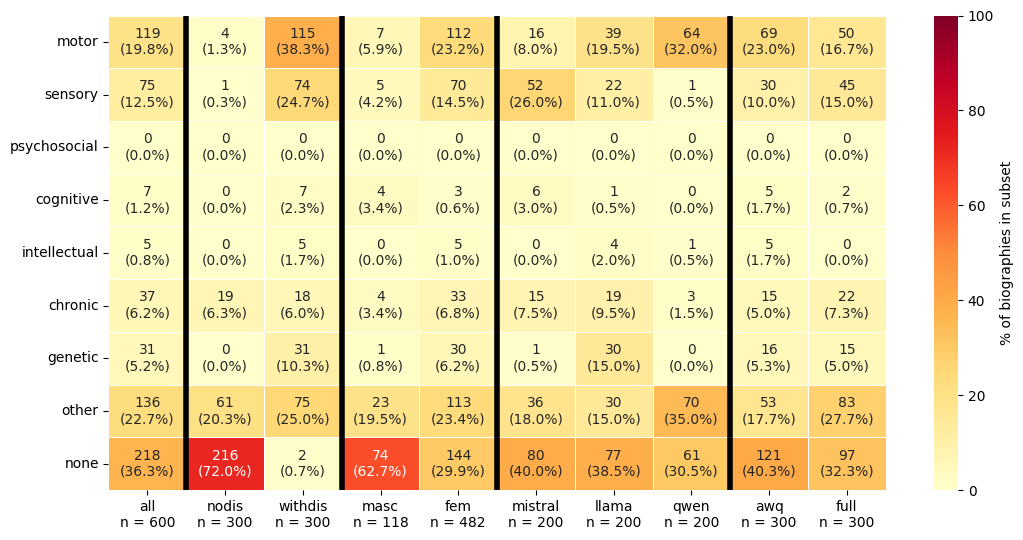

In [12]:
# Heatmap of the table above: share of biographies mentioning each category
# (rows) in each parameter subset (columns)
fig, ax = plt.subplots(figsize=(11, 5.5))

# cell annotations combine the raw count and the percentage
annot = df_counts_dis.astype(int).astype(str) + "\n(" + df_pct_dis.round(1).astype(str) + "%)"

# family separators, computed before the columns are relabelled
boundaries = family_boundaries(list(df_pct_dis.columns))

# subset size under each column name, e.g. 'masc\nn = 118'
col_labels = {c: f"{c}\nn = {SIZES[c]}" for c in df_pct_dis.columns}
pct_plot = df_pct_dis.rename(columns=col_labels)
annot = annot.rename(columns=col_labels)

sns.heatmap(pct_plot, annot=annot, fmt="", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "% of biographies in subset"}, vmin=0, vmax=100, ax=ax)

# thick black lines between parameter families
for x in boundaries:
    ax.axvline(x, color="black", linewidth=4)
save_show("disabilities_cat_parameters_matrix.pdf")

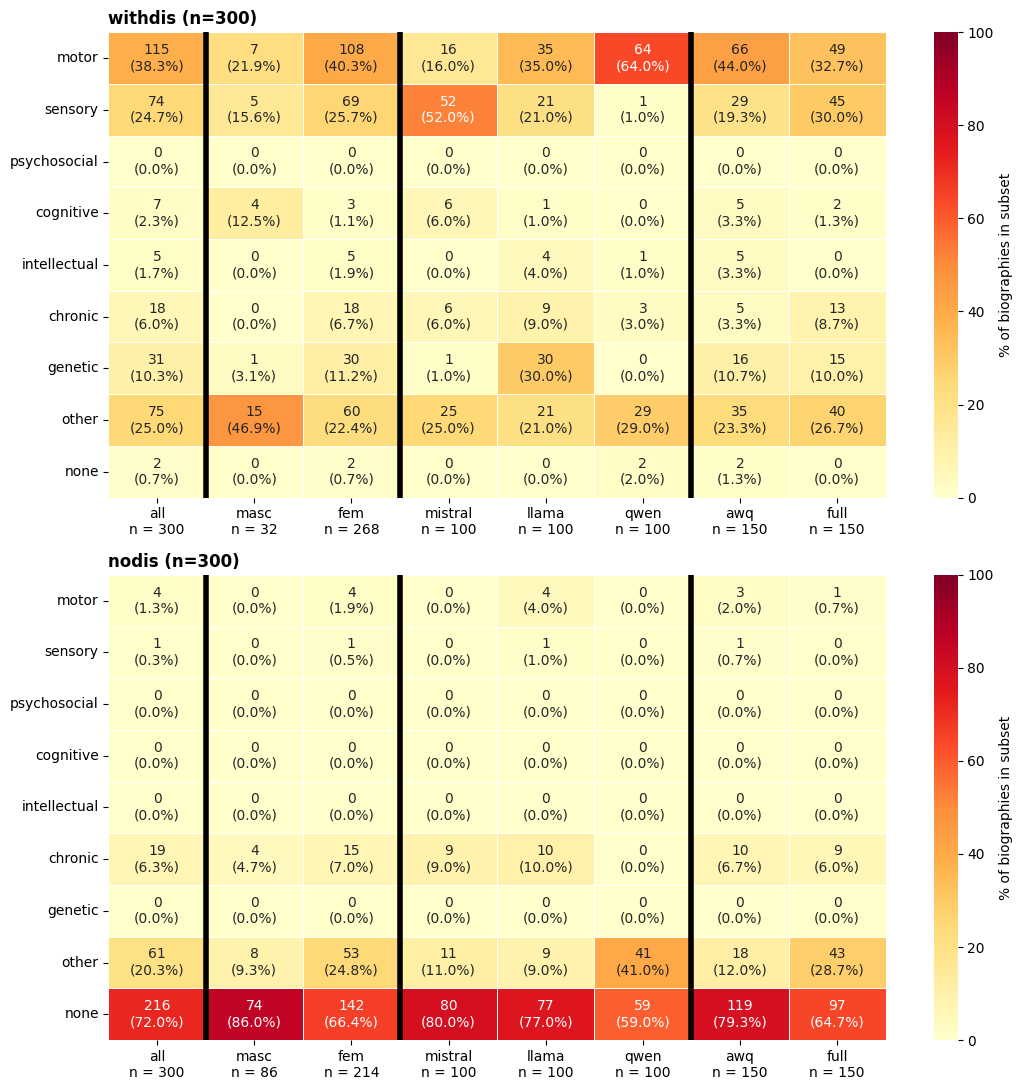

In [13]:
# Same heatmap, computed separately on the withdis and nodis biographies. The
# prompt family is excluded from the columns since it is the splitting variable.
COND_FAMILIES = {f: p for f, p in FAMILIES.items() if f != "prompt"}
COND_PARAMS = {"all": None,
               **{p: sel for fam in COND_FAMILIES.values() for p, sel in fam.items()}}

fig, axes = plt.subplots(2, 1, figsize=(11, 11), sharex=False)

for ax, (variant, keep) in zip(axes, [("withdis", True), ("nodis", False)]):
    # subsets, sizes and tables are recomputed within the variant
    df_var = df_rep[df_rep["disability_in_prompt"] == keep]
    subsets_var = make_subsets(df_var, COND_PARAMS)
    sizes_var = {p: len(sub) for p, sub in subsets_var.items()}
    df_counts_var, df_pct_var = count_pct_table(DIS_ROWS, subsets_var, sizes_var)
    df_counts_var = df_counts_var.rename(index=RENAME)
    df_pct_var = df_pct_var.rename(index=RENAME)

    annot = df_counts_var.astype(int).astype(str) + "\n(" + df_pct_var.round(1).astype(str) + "%)"

    # family separators, computed before the columns are relabelled
    boundaries = family_boundaries(list(df_pct_var.columns), COND_FAMILIES)

    # subset size under each column name
    col_labels = {c: f"{c}\nn = {sizes_var[c]}" for c in df_pct_var.columns}
    df_pct_var = df_pct_var.rename(columns=col_labels)
    annot = annot.rename(columns=col_labels)

    sns.heatmap(df_pct_var, annot=annot, fmt="", cmap="YlOrRd", linewidths=0.5,
                cbar_kws={"label": "% of biographies in subset"}, vmin=0, vmax=100, ax=ax)
    for x in boundaries:
        ax.axvline(x, color="black", linewidth=4)
    ax.set_title(f"{variant} (n={sizes_var['all']})", fontsize=12,
                 fontweight="bold", loc="left")

fig.tight_layout()
save_show("disabilities_cat_parameters_matrix_by_variant.pdf")

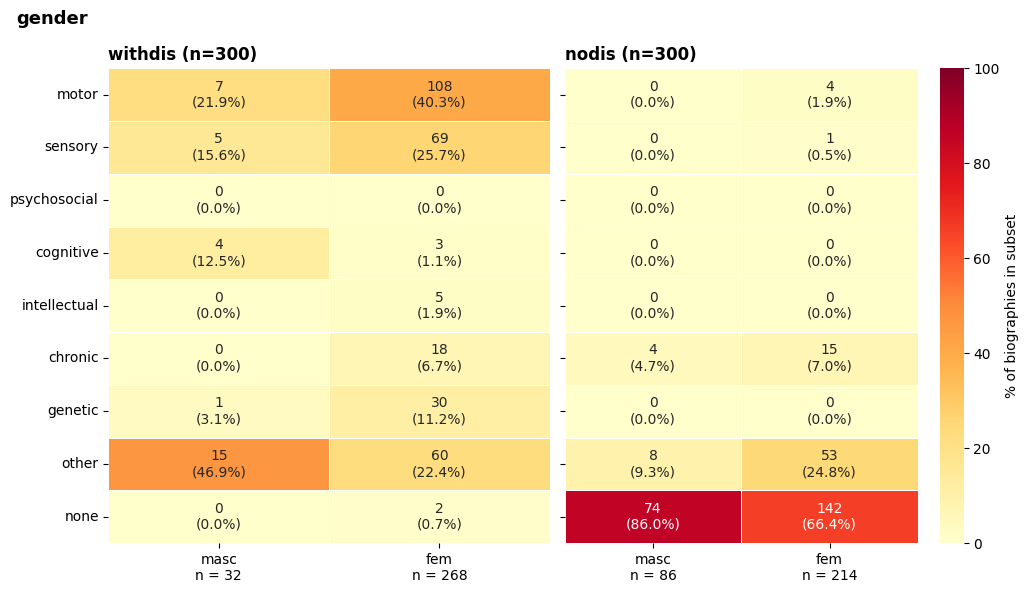

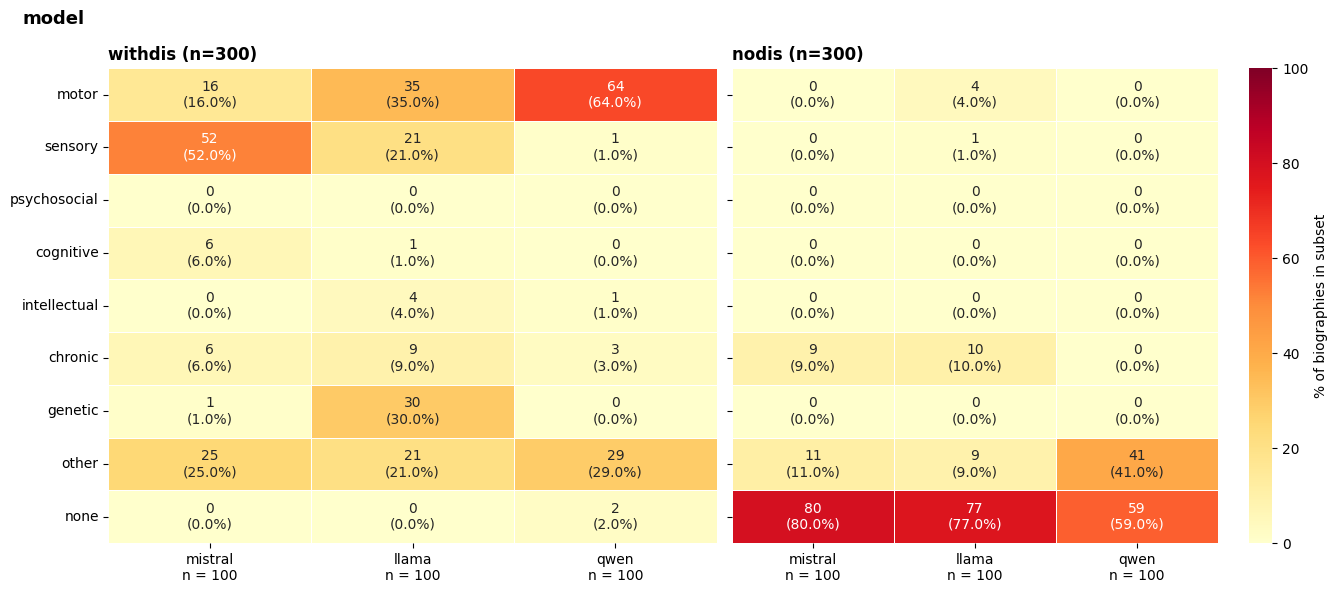

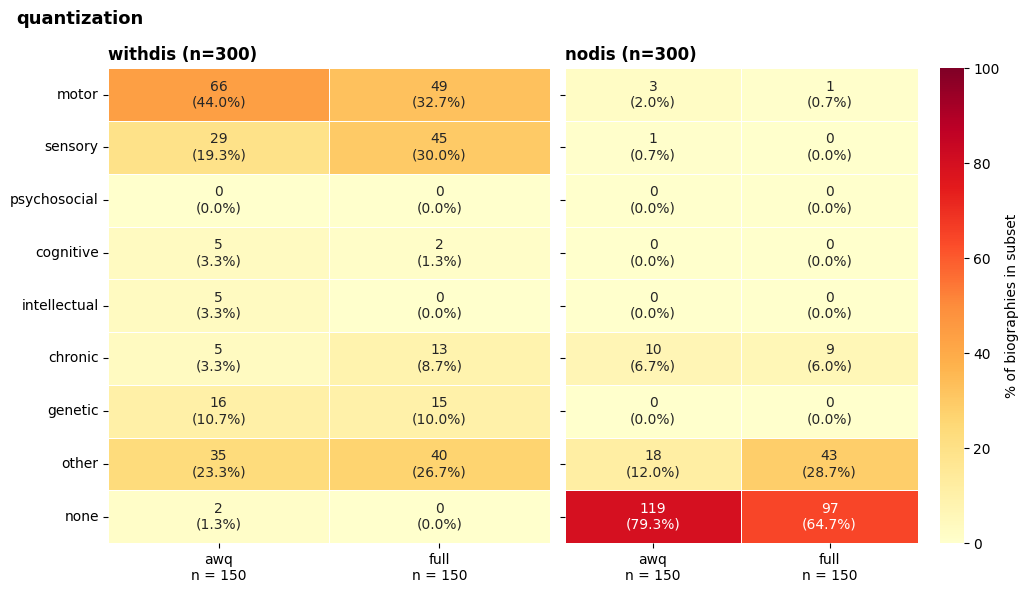

In [14]:
# One figure per family: withdis and nodis heatmaps side by side, restricted
# to that family's subsets, so within-family comparisons are easier to read
VARIANTS = {"withdis": df_rep["disability_in_prompt"],
            "nodis":  ~df_rep["disability_in_prompt"]}

for family_name, params in COND_FAMILIES.items():
    cols = dict(params)

    # figure width scales with the number of family members
    fig, axes = plt.subplots(1, 2, figsize=(2 * (1.6 * len(cols) + 2), 6),
                             sharey=True)

    for ax, (variant_name, mask) in zip(axes, VARIANTS.items()):
        df_var  = df_rep[mask]
        subsets = make_subsets(df_var, cols)
        sizes   = {p: len(s) for p, s in subsets.items()}
        df_counts, df_pct = count_pct_table(DIS_ROWS, subsets, sizes)
        df_counts = df_counts.rename(index=RENAME)
        df_pct    = df_pct.rename(index=RENAME)

        annot = (df_counts.astype(int).astype(str)
                 + "\n(" + df_pct.round(1).astype(str) + "%)")

        col_labels = {c: f"{c}\nn = {sizes[c]}" for c in df_pct.columns}
        df_pct = df_pct.rename(columns=col_labels)
        annot  = annot.rename(columns=col_labels)

        # single colorbar for the figure, attached to the right-hand panel
        is_last = ax is axes[-1]
        sns.heatmap(df_pct, annot=annot, fmt="", cmap="YlOrRd", linewidths=0.5,
                    vmin=0, vmax=100, ax=ax,
                    cbar=is_last,
                    cbar_kws={"label": "% of biographies in subset"} if is_last else None)
        ax.set_title(f"{variant_name} (n={len(df_var)})", fontsize=12,
                     fontweight="bold", loc="left")

    fig.suptitle(family_name, fontsize=13, fontweight="bold", x=0.02, ha="left")
    fig.tight_layout()
    save_show(f"disabilities_cat_matrix_{family_name}_by_variant.pdf")

### Statistical analyses

In [15]:
# Chi-squared test of independence
# Answers: does requiring a disability in the prompt change whether any disability is mentioned in the biography?
df_rep["any_disability"] = ~df_rep["none"]

expected, observed, stats = pg.chi2_independence(
    df_rep, x="disability_in_prompt", y="any_disability",
    correction=False)
stats[stats["test"] == "pearson"]

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.0,329.958211,1.0,9.814971e-74,0.741573,1.0


In [16]:
# Linear probability model on the withdis biographies
# Answers: does the probability of mentioning each disability category depend on gender, model or quantization?
d = df_rep[df_rep["disability_in_prompt"]].copy()

# long format: one row per (biography, category) with a 0/1 outcome
long_df = d.melt(
    id_vars=["doc_id", "genre_auto", "model", "quant"],
    value_vars=DIS_ROWS,
    var_name="category", value_name="present")
long_df["present"] = long_df["present"].astype(int)
long_df["category"] = long_df["category"].map(lambda c: RENAME.get(c, c))

# 'psychiques' and 'none' are too rare in this subset to estimate effects so we remove them
KEEP_CATS = [RENAME.get(c, c) for c in DIS_ROWS
             if RENAME.get(c, c) not in ("psychiques", "none")]
long_df = long_df[long_df["category"].isin(KEEP_CATS)].copy()

# category-specific baselines (no global intercept) + category x parameter interactions, so each parameter may shift each category differently
formula = ("present ~ 0 + C(category)"
           " + C(category):C(genre_auto)"
           " + C(category):C(model)"
           " + C(category):C(quant)")

# cluster-robust standard errors: the category rows coming from the same biography are not independent observations
res = smf.ols(formula, data=long_df).fit(
    cov_type="cluster", cov_kwds={"groups": long_df["doc_id"]})
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                present   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 12 Aug 2026   Prob (F-statistic):                nan
Time:                        11:24:44   Log-Likelihood:                -417.48
No. Observations:                2400   AIC:                             915.0
Df Residuals:                    2360   BIC:                             1146.
Df Model:                          39                                         
Covariance Type:              cluster                                         
===================================================================================================================
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
C(category)[chronic]                                0.0695      0.029      2.375      0.018       0.012       0.127
C(category)[cognitive]                              0.0121      0.009      1.337      0.181      -0.006       0.030
C(category)[genetic]                                0.3053      0.049      6.188      0.000       0.209       0.402
C(category)[intellectual]                           0.0581      0.027      2.170      0.030       0.006       0.111
C(category)[motor]                                  0.4055      0.056      7.231      0.000       0.296       0.515
C(category)[other]                                  0.1659      0.047      3.558      0.000       0.075       0.257
C(category)[psychosocial]                         1.89e-16    1.3e-16      1.453      0.146    -6.6e-17    4.44e-16
C(category)[sensory]                                0.1925      0.046      4.179      0.000       0.102       0.283
C(category)[chronic]:C(genre_auto)[T.Masc]         -0.0714      0.027     -2.665      0.008      -0.124      -0.019
C(category)[cognitive]:C(genre_auto)[T.Masc]        0.0917      0.057      1.601      0.109      -0.021       0.204
C(category)[genetic]:C(genre_auto)[T.Masc]         -0.0226      0.039     -0.573      0.566      -0.100       0.055
C(category)[intellectual]:C(genre_auto)[T.Masc]    -0.0168      0.009     -1.982      0.047      -0.034      -0.000
C(category)[motor]:C(genre_auto)[T.Masc]            0.0140      0.083      0.168      0.867      -0.149       0.177
C(category)[other]:C(genre_auto)[T.Masc]            0.3167      0.098      3.230      0.001       0.125       0.509
C(category)[psychosocial]:C(genre_auto)[T.Masc] -3.528e-16   2.71e-16     -1.300      0.193   -8.85e-16    1.79e-16
C(category)[sensory]:C(genre_auto)[T.Masc]         -0.4135      0.090     -4.580      0.000      -0.590      -0.237
C(category)[chronic]:C(model)[T.mistral]           -0.0129      0.041     -0.316      0.752      -0.093       0.067
C(category)[cognitive]:C(model)[T.mistral]          0.0280      0.022      1.277      0.202      -0.015       0.071
C(category)[genetic]:C(model)[T.mistral]           -0.2846      0.049     -5.838      0.000      -0.380      -0.189
C(category)[intellectual]:C(model)[T.mistral]      -0.0360      0.018     -2.007      0.045      -0.071      -0.001
C(category)[motor]:C(model)[T.mistral]             -0.1934      0.062     -3.112      0.002      -0.315      -0.072
C(category)[other]:C(model)[T.mistral]             -0.0360      0.060     -0.605      0.545      -0.153       0.081
C(category)[psychosocial]:C(model)[T.mistral]    -3.76e-16   1.56e-16     -2.415      0.016   -6.81e-16   -7.09e-17
C(category)[sensory]:C(model)[T.mistral]            0.4092      0.0

In [17]:
# Joint significance of each group of terms
res.wald_test_terms(scalar=True).table

,statistic,pvalue,df_constraint
C(category),858.241859,4.983712e-181,8
C(category):C(genre_auto),40.877507,8.546330e-07,8
C(category):C(model),237.053653,1.356373e-42,16
C(category):C(quant),18.554510,9.703573e-03,8


In [18]:
# Tidy coefficient table extracted from the fitted model
tidy = pd.DataFrame({"coef": res.params, "se": res.bse, "p": res.pvalues})

# statsmodels terms look like 'C(category)[cat]:C(var)[T.lvl]':
# extract the category and, for interaction terms, the (variable, level) pair
pattern = re.compile(r"C\(category\)\[(?P<cat>[^\]]+)\]"
                     r"(?::C\((?P<var>\w+)\)\[T\.(?P<lvl>[^\]]+)\])?")
parts = tidy.index.str.extract(pattern)
tidy["category"] = parts["cat"].values
tidy["term"] = np.where(parts["var"].isna(), "baseline",
                        parts["var"] + ": " + parts["lvl"])

# Benjamini-Hochberg correction over the interaction effects only,
# then 'coefficient + stars' cell labels (baselines keep the bare coefficient)
eff = tidy["term"] != "baseline"
tidy.loc[eff, "p_bh"] = multipletests(tidy.loc[eff, "p"], method="fdr_bh")[1]
tidy["cell"] = tidy["coef"].round(2).astype(str) + tidy["p_bh"].map(stars)
tidy.loc[~eff, "cell"] = tidy.loc[~eff, "coef"].round(2).astype(str)

TERM_ORDER = ["baseline", "genre_auto: Masc", "model: mistral",
              "model: qwen", "quant: torch"]
grid = (tidy.pivot(index="category", columns="term", values="cell")
            [TERM_ORDER]
            .rename(columns={"baseline": "baseline P(cat) (Fem/llama/awq)"}))
grid

term,baseline P(cat) (Fem/llama/awq),genre_auto: Masc,model: mistral,model: qwen,quant: torch
category,,,,,
chronic,0.07,-0.07*,-0.01,-0.06,0.05
cognitive,0.01,0.09,0.03,-0.01,-0.01
genetic,0.31,-0.02,-0.28***,-0.3***,-0.01
intellectual,0.06,-0.02,-0.04,-0.03,-0.03
motor,0.41,0.01,-0.19**,0.29***,-0.11
other,0.17,0.32**,-0.04,0.09,0.06
psychosocial,0.0,-0.0,-0.0,-0.0,-0.0
sensory,0.19,-0.41***,0.41***,-0.22***,0.07


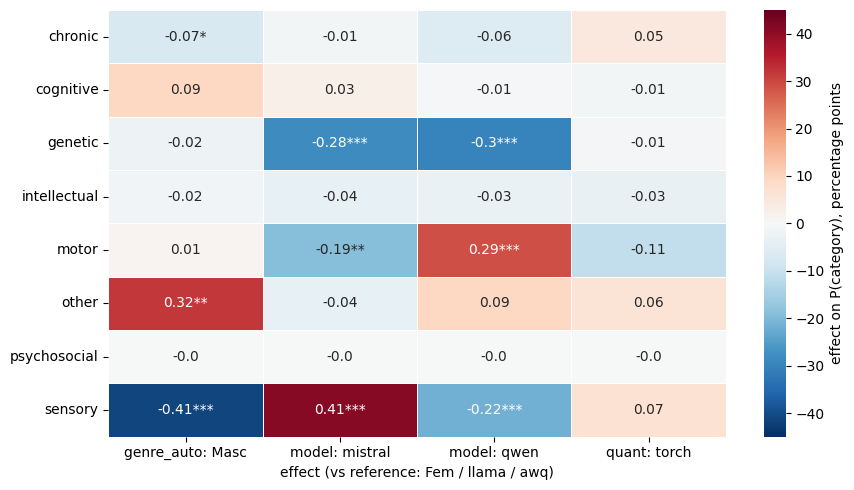

In [19]:
# Heatmap of the interaction effects, in percentage points; 
# annotations reuse the 'coefficient + stars' labels from the table above
coef_grid = tidy.pivot(index="category", columns="term", values="coef")[TERM_ORDER[1:]]
annot_grid = tidy.pivot(index="category", columns="term", values="cell")[TERM_ORDER[1:]]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(coef_grid * 100, annot=annot_grid, fmt="", cmap="RdBu_r",
            center=0, vmin=-45, vmax=45, linewidths=0.5,
            cbar_kws={"label": "effect on P(category), percentage points"}, ax=ax)
ax.set_xlabel("effect (vs reference: Fem / llama / awq)")
ax.set_ylabel("")
save_show("lpm_effects_heatmap.pdf")

In [20]:
# Logistic regressions on the same subset, as a robustness check of the linear model: 
# one logit per sufficiently frequent category, reported as odds ratios
d = df_rep[df_rep["disability_in_prompt"]].copy()

LOGIT_CATS = ["handicaps moteurs", "handicaps sensoriels", "other"]

logit_rows, logit_fits = [], {}
for cat in LOGIT_CATS:
    # formula-friendly column name, e.g. 'mal. chroniques' -> 'mal_chroniques'
    y = RENAME.get(cat, cat).replace(". ", "_").replace(" ", "_")
    d[y] = d[cat].astype(int)
    m = smf.logit(f"{y} ~ C(genre_auto) + C(model) + C(quant)", data=d).fit(disp=0)
    logit_fits[cat] = m
    # odds ratios and their 95% CI are the exponentiated coefficients
    ci = np.exp(m.conf_int())
    for term in m.params.index:
        logit_rows.append({
            "category": RENAME.get(cat, cat), "term": term,
            "beta": m.params[term], "OR": np.exp(m.params[term]),
            "OR_ci_low": ci.loc[term, 0], "OR_ci_high": ci.loc[term, 1],
            "p": m.pvalues[term],
            "converged": m.mle_retvals["converged"],
        })

df_logit = pd.DataFrame(logit_rows)

# BH correction across all non-intercept terms
eff = df_logit["term"] != "Intercept"
df_logit.loc[eff, "p_bh"] = multipletests(df_logit.loc[eff, "p"],
                                          method="fdr_bh")[1]
df_logit["stars"] = df_logit["p_bh"].map(stars)

df_logit.to_csv(OUTPUT_DIR / "logit_withdis_OR.csv", index=False)
print(df_logit[eff][["category", "term", "OR", "OR_ci_low", "OR_ci_high",
               "p", "p_bh", "stars"]].round(3))

   category                   term     OR  OR_ci_low  OR_ci_high      p  \
1     motor  C(genre_auto)[T.Masc]  1.171      0.426       3.217  0.760   
2     motor    C(model)[T.mistral]  0.333      0.159       0.698  0.004   
3     motor       C(model)[T.qwen]  3.403      1.891       6.123  0.000   
4     motor      C(quant)[T.torch]  0.565      0.336       0.953  0.032   
6   sensory  C(genre_auto)[T.Masc]  0.129      0.044       0.382  0.000   
7   sensory    C(model)[T.mistral]  6.683      3.367      13.263  0.000   
8   sensory       C(model)[T.qwen]  0.036      0.005       0.273  0.001   
9   sensory      C(quant)[T.torch]  1.666      0.868       3.198  0.125   
11    other  C(genre_auto)[T.Masc]  4.776      1.953      11.676  0.001   
12    other    C(model)[T.mistral]  0.802      0.380       1.692  0.562   
13    other       C(model)[T.qwen]  1.676      0.870       3.229  0.123   
14    other      C(quant)[T.torch]  1.425      0.822       2.468  0.207   

     p_bh stars  
1   0.

In [21]:
# Sanity check: number of positive cases per model for the categories above
pos_counts = (d.groupby("model")[[RENAME.get(c, c).replace(". ", "_").replace(" ", "_")
                                  for c in LOGIT_CATS]]
                .sum())
display(pos_counts)

# 'maladies génétiques' is left out of LOGIT_CATS: qwen produces no positive case at all, so the logit suffers from perfect separation and does not converge
# (hence the huge negative qwen coefficient below)
d["mal_genetiques"] = d["maladies génétiques"].astype(int)
m_sep = smf.logit("mal_genetiques ~ C(genre_auto) + C(model) + C(quant)",
                  data=d).fit(disp=0)
print("converged:", m_sep.mle_retvals["converged"],
      "| beta qwen:", round(m_sep.params["C(model)[T.qwen]"], 1))

,motor,sensory,other
model,,,
llama,35,21,21
mistral,16,52,25
qwen,64,1,29


converged: False | beta qwen: -22.4


## Gender representation

### Statistics table

In [22]:
# Count and share of feminine / masculine biographies per subset
df_counts_gen, df_pct_gen = count_pct_table([f"is_{g}" for g in GENDERS], SUBSETS, SIZES)
df_counts_gen = df_counts_gen.rename(index=lambda r: r.removeprefix("is_"))
df_pct_gen = df_pct_gen.rename(index=lambda r: r.removeprefix("is_"))

GENDER_PARAMS = [p for p in PARAMS if p not in FAMILIES["gender"]]
df_counts_gen = df_counts_gen[GENDER_PARAMS]
df_pct_gen = df_pct_gen[GENDER_PARAMS]

display_table(df_counts_gen, df_pct_gen, SIZES)

,all,nodis,withdis,mistral,llama,qwen,awq,full
Fem,482 (80.3%),214 (71.3%),268 (89.3%),131 (65.5%),165 (82.5%),186 (93.0%),216 (72.0%),266 (88.7%)
Masc,118 (19.7%),86 (28.7%),32 (10.7%),69 (34.5%),35 (17.5%),14 (7.0%),84 (28.0%),34 (11.3%)
total,600,300,300,200,200,200,300,300


### Visualization

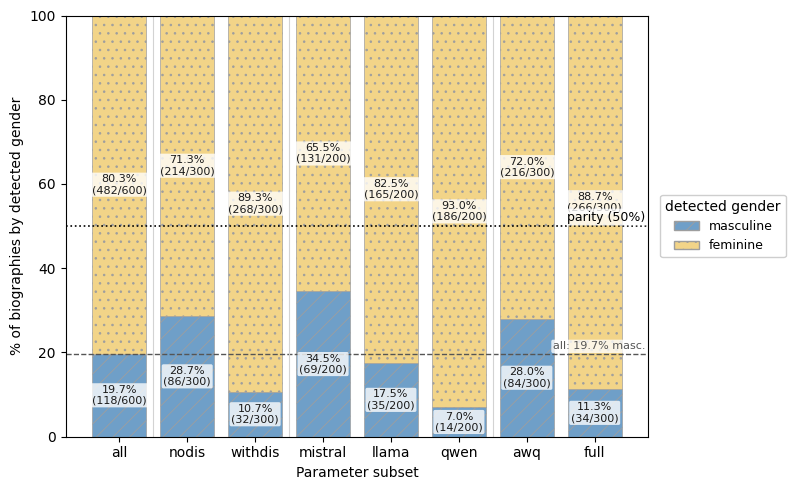

In [23]:
# 100% stacked bars of detected gender per subset.
fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(GENDER_PARAMS))

# masculine at the bottom, feminine stacked on top
bottom = np.zeros(len(GENDER_PARAMS))
for g in ["Masc", "Fem"]:
    st = GENDER_STYLE[g]
    vals = df_pct_gen.loc[g, GENDER_PARAMS].to_numpy(dtype=float)
    ax.bar(x, vals, bottom=bottom, color=st["color"], hatch=st["hatch"],
           edgecolor=HATCH_COLOR, linewidth=0.5, label=st["label"])
    # percentage + count in the middle of each segment
    for xi, p in enumerate(GENDER_PARAMS):
        v = vals[xi]
        if v >= 6:                 # skip segments too short to hold text
            ax.text(xi, bottom[xi] + v / 2,
                    f"{v:.1f}%\n({df_counts_gen.loc[g, p]}/{SIZES[p]})",
                    ha="center", va="center", fontsize=8, color="#1a1a1a",
                    linespacing=1.1, bbox=LABEL_BBOX)
    bottom += vals

# parity reference line at 50%
ax.axhline(50, color="black", linestyle=":", linewidth=1.2)
ax.text(0.995, 50.6, "parity (50%)", transform=ax.get_yaxis_transform(),
        ha="right", va="bottom", fontsize=9, color="black", bbox=LABEL_BBOX)

# overall masculine share (from the 'all' subset) as a second reference
baseline = df_pct_gen.loc["Masc", "all"]
ax.axhline(baseline, color="#555555", linestyle="--", linewidth=1)
ax.text(0.995, baseline + 0.6, f"all: {baseline:.1f}% masc.",
        transform=ax.get_yaxis_transform(), ha="right", va="bottom",
        fontsize=8, color="#555555", bbox=LABEL_BBOX)

# light separators between parameter families
for b in family_boundaries(GENDER_PARAMS):
    ax.axvline(b - 0.5, color="lightgrey", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(GENDER_PARAMS)
ax.set_ylim(0, 100)
ax.set_ylabel("% of biographies by detected gender")
ax.set_xlabel("Parameter subset")

# legend outside the axes: the full-height bars leave no room inside
legend_handles = [Patch(facecolor=GENDER_STYLE[g]["color"], hatch=GENDER_STYLE[g]["hatch"],
                        edgecolor=HATCH_COLOR, label=GENDER_STYLE[g]["label"])
                  for g in ["Masc", "Fem"]]
ax.legend(handles=legend_handles, title="detected gender",
          loc="center left", bbox_to_anchor=(1.01, 0.5),
          framealpha=0.95, fontsize=9)

# reserve room on the right so the external legend is not clipped
save_show("genders_parameters_bars.pdf", rect=[0, 0, 0.85, 1])

### Statistical analysis

In [24]:
# Chi-squared test of independence between model and detected gender, on the withdis biographies
d = df_rep[df_rep["disability_in_prompt"]]

expected, observed, stats_gm = pg.chi2_independence(
    d, x="model", y="genre_auto", correction=False)

display(observed)
display(expected.round(1))
stats_gm[stats_gm["test"] == "pearson"]

genre_auto,Fem,Masc
model,,
llama,96,4
mistral,72,28
qwen,100,0


genre_auto,Fem,Masc
model,,
llama,89.3,10.7
mistral,89.3,10.7
qwen,89.3,10.7


,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.0,48.134328,2.0,3.529908e-11,0.400559,0.999998


In [25]:
# Same test on the full set of biographies
expected, observed, stats_all = pg.chi2_independence(
    df_rep, x="model", y="genre_auto", correction=False)
stats_all[stats_all["test"] == "pearson"]

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.0,48.758703,2.0,2.583343e-11,0.285069,0.999998


In [26]:
# Same test for quantization
expected, observed, stats_qg = pg.chi2_independence(
    df_rep, x="quant", y="genre_auto", correction=False)
print(stats_qg[stats_qg["test"] == "pearson"])
print(expected)

      test  lambda       chi2  dof          pval    cramer     power
0  pearson     1.0  26.373163  1.0  2.814237e-07  0.209655  0.999252
genre_auto    Fem  Masc
quant                  
awq         241.0  59.0
torch       241.0  59.0


## Location representation

### Visualization

In [27]:
def plot_top_overall(subsets, sizes, col, fname, top_n=10,
                     item_kind="first name", param="all"):
    sub, n_sub = subsets[param], sizes[param]
    counter = Counter(x for lst in sub[col] for x in lst)
    top_items = [x for x, _ in counter.most_common(top_n)]
 
    cnts = [int(sub[col].apply(lambda l: it in l).sum()) for it in top_items]
    pcts = [100 * c / n_sub for c in cnts]
 
    fig, ax = plt.subplots(figsize=(9, 5))
    y = range(len(top_items))[::-1]          # most frequent on top
    bars = ax.barh(list(y), pcts, height=0.7, color=PARAM_COLORS["all"],
                   edgecolor=HATCH_COLOR, linewidth=0.5)
    ax.bar_label(bars, labels=[f"{p:.0f}% ({c}/{n_sub})" for p, c in zip(pcts, cnts)],
                 fontsize=8, padding=2, color="#1a1a1a", bbox=LABEL_BBOX)
 
    ax.set_yticks(list(y))
    ax.set_yticklabels(top_items)
    ax.set_xlabel(f"% of biographies mentioning the {item_kind}")
    ax.set_ylabel(item_kind.capitalize())
    ax.set_title(f"Top {len(top_items)} {item_kind}s over the whole corpus (n={n_sub})")
    ax.set_xlim(0, ax.get_xlim()[1] * 1.15)  # room for the bar labels
    save_show(fname)

    

def plot_top_locations(param_names, subsets, sizes, locations, legend_title,
                       fname, top_n=10):
    """Horizontal grouped bars: % of biographies mentioning each of the top_n locations (computed over `locations`, a Series of lists), one bar
    per parameter subset in param_names. 
    """
    # rank locations over the whole corpus, so every subset shares the same axis
    locs_counter = Counter(x for lst in locations for x in lst)
    top_locs = [loc for loc, _ in locs_counter.most_common(top_n)]

    fig, ax = plt.subplots(figsize=(9, 6))
    y = range(top_n)[::-1]           # most frequent location on top
    h = 0.8 / len(param_names)       # bar height within each location group
    for i, p in enumerate(param_names):
        sub, n_sub = subsets[p], sizes[p]
        cnts = [int(sub["locations_parsed"].apply(lambda l: loc in l).sum())
                for loc in top_locs]
        pcts = [100 * c / n_sub for c in cnts]
        # vertical offset of this subset's bars within each group
        offs = [yi + ((len(param_names) - 1) / 2 - i) * h for yi in y]
        bars = ax.barh(offs, pcts, height=h, color=PARAM_COLORS.get(p, f"C{i}"),
                       hatch=PARAM_HATCH.get(p, ""), edgecolor=HATCH_COLOR,
                       linewidth=0.5, label=p)
        ax.bar_label(bars, labels=[f"{pc:.0f}% ({c}/{n_sub})"
                                   for pc, c in zip(pcts, cnts)],
                     fontsize=8, padding=2, color="#1a1a1a", bbox=LABEL_BBOX)

    ax.set_yticks(list(y))
    ax.set_yticklabels(top_locs)
    ax.set_xlabel("% of biographies mentioning the location")
    ax.set_ylabel("Location")
    ax.set_xlim(0, ax.get_xlim()[1] * 1.18)    # room for the bar labels
    ax.legend(title=legend_title, loc="lower right", framealpha=0.95)
    save_show(fname)

LEGENDS = {"model": "Model", "prompt": "Prompt",
           "gender": "Gender", "quantization": "Quantization"}

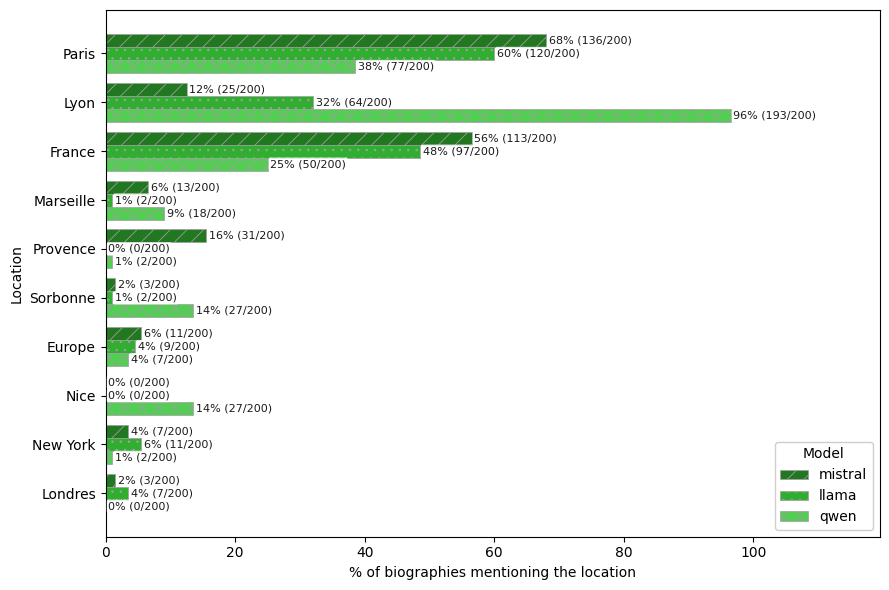

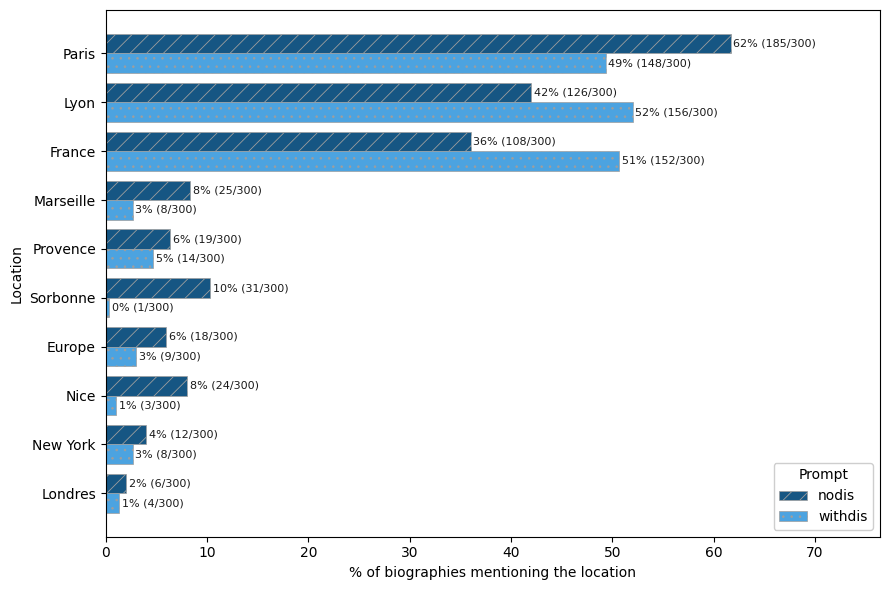

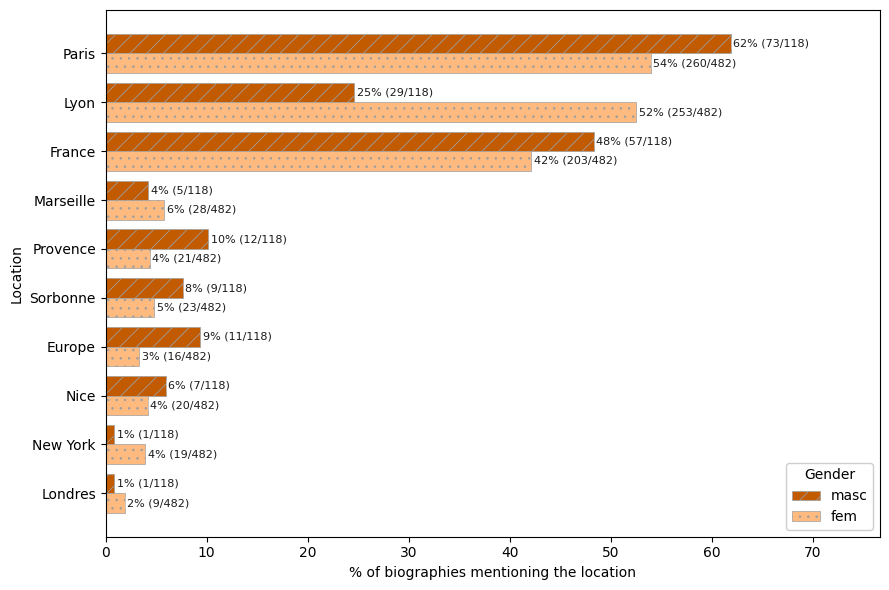

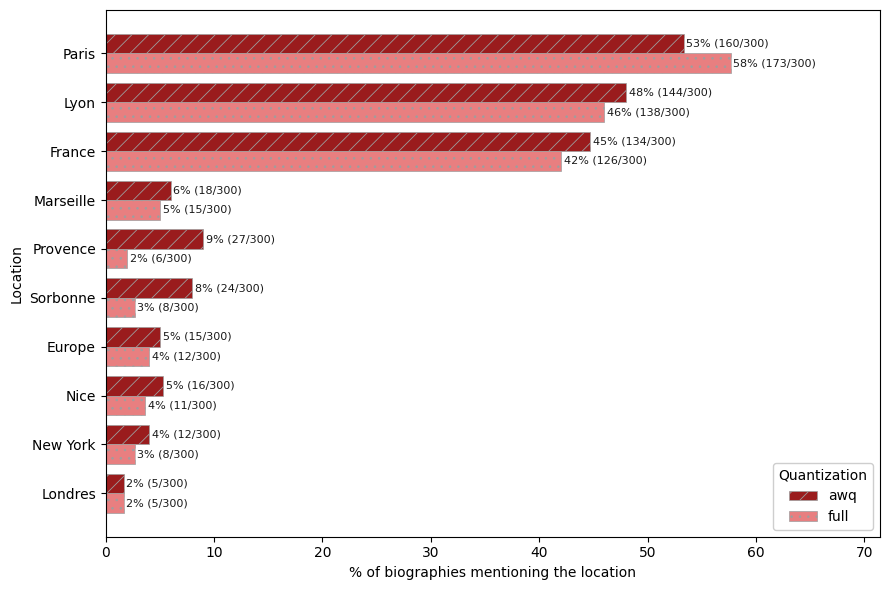

In [28]:
for family, legend in LEGENDS.items():
    plot_top_locations(
        param_names=list(FAMILIES[family]),
        subsets=SUBSETS, sizes=SIZES,
        locations=df_rep["locations_parsed"],
        legend_title=legend,
        fname=f"locations_{family}.pdf")

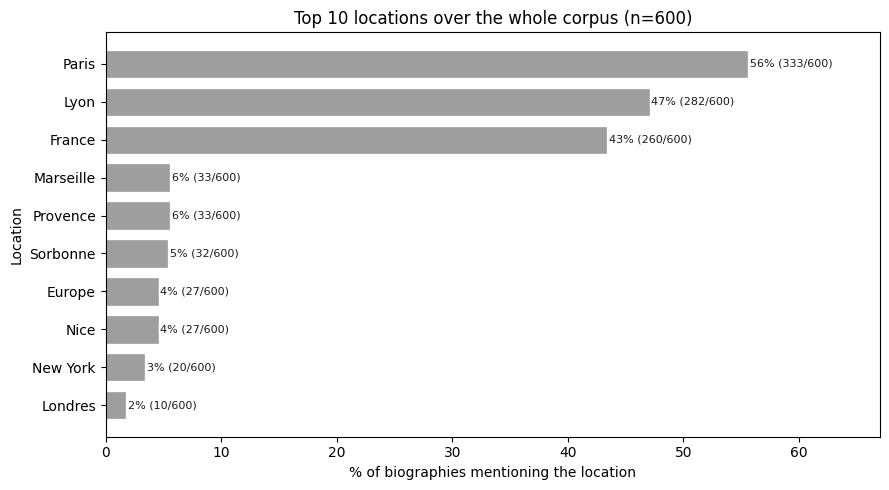

In [29]:
plot_top_overall(SUBSETS, SIZES, "locations_parsed", fname="top_locations_all.pdf", item_kind="location")

# Names representation

## Visualization

In [30]:
df_rep

,Unnamed: 0,doc_id,bio,genre_auto,Detailed_counter,Detailed_markers,model,prompt_version,disability_in_prompt,run,...,handicaps psychiques,handicaps cognitifs,handicaps mentaux,maladies chroniques évolutives ou invalidantes,maladies génétiques,none,other,is_Fem,is_Masc,any_disability
0,0,llama_v1_long_nodis_0_awq.txt,Léonard Dupont est né le 12 février 1875 à Lyo...,Masc,Counter({'Masc': 7}),"[né, homme, 'laisse derrière lui', associé, co...",llama,v1_long,False,0,...,False,False,False,False,False,True,False,False,True,False
1,1,llama_v1_long_nodis_0_torch.txt,Sophie Lefebvre naît le 12 février 1885 dans u...,Fem,Counter({'Fem': 4}),"[fille, 'laissant derrière elle', 'elle (prono...",llama,v1_long,False,0,...,False,False,False,False,False,True,False,True,False,False
2,2,llama_v1_long_nodis_10_awq.txt,"Suzanne Dupont naît le 15 février 1955 à Lyon,...",Fem,Counter({'Fem': 2}),['elle (pronom majoritaire)'],llama,v1_long,False,10,...,False,False,False,True,False,False,False,True,False,True
3,3,llama_v1_long_nodis_10_torch.txt,Jean-Luc Dumont naît en 1955 dans une petite v...,Masc,Counter({'Masc': 5}),"[écrivain, reconnu, 'laissant derrière lui', '...",llama,v1_long,False,10,...,False,False,False,False,False,True,False,False,True,False
4,4,llama_v1_long_nodis_11_awq.txt,"La vie de Sophie Dupont, une artiste visionnai...",Fem,"Counter({'Fem': 5, 'Masc': 4})","[artiste, artiste, artiste, canadien, diplomat...",llama,v1_long,False,11,...,False,False,False,False,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,595,qwen_v1_long_withdis_7_torch.txt,"Léa Martin est née le 15 avril 1985 à Lyon, en...",Fem,Counter({'Fem': 4}),"[née, 'laissant derrière elle', 'elle (pronom ...",qwen,v1_long,True,7,...,False,False,False,False,False,False,False,True,False,True
596,596,qwen_v1_long_withdis_8_awq.txt,"Élise Moreau est née le 12 avril 1985 à Lyon, ...",Fem,Counter({'Fem': 6}),"[née, illustratrice, 'laissant derrière elle',...",qwen,v1_long,True,8,...,False,False,False,False,False,False,True,True,False,True
597,597,qwen_v1_long_withdis_8_torch.txt,"Élise Moreau est née le 12 mai 1985 à Lyon, da...",Fem,Counter({'Fem': 5}),"[née, illustratrice, 'laissant derrière elle',...",qwen,v1_long,True,8,...,False,False,False,True,False,False,False,True,False,True
598,598,qwen_v1_long_withdis_9_awq.txt,"Élodie Martin est née le 12 avril 1958 à Lyon,...",Fem,Counter({'Fem': 4}),"[née, conseillère, 'elle (pronom majoritaire)']",qwen,v1_long,True,9,...,False,False,True,False,False,False,False,True,False,True


In [31]:
def plot_top_names(param_names, subsets, sizes, names, col, legend_title,
                   fname, top_n=10, name_kind="first name"):
    """
    Horizontal grouped bars: % of biographies mentioning each of the top_n names (computed over `names`, a Series of lists), one bar per parameter
    subset in param_names. `col` is the column counted within each subset.
    """
    # rank names over the whole corpus, so every subset shares the same axis
    names_counter = Counter(x for lst in names for x in lst)
    top_names = [n for n, _ in names_counter.most_common(top_n)]
 
    fig, ax = plt.subplots(figsize=(9, 6))
    y = range(len(top_names))[::-1]     # most frequent name on top
    h = 0.8 / len(param_names)          # bar height within each name group
    for i, p in enumerate(param_names):
        sub, n_sub = subsets[p], sizes[p]
        cnts = [int(sub[col].apply(lambda l: nm in l).sum()) for nm in top_names]
        pcts = [100 * c / n_sub for c in cnts]
        # vertical offset of this subset's bars within each group
        offs = [yi + ((len(param_names) - 1) / 2 - i) * h for yi in y]
        bars = ax.barh(offs, pcts, height=h, color=PARAM_COLORS.get(p, f"C{i}"),
                       hatch=PARAM_HATCH.get(p, ""), edgecolor=HATCH_COLOR,
                       linewidth=0.5, label=p)
        ax.bar_label(bars, labels=[f"{pc:.0f}% ({c}/{n_sub})"
                                   for pc, c in zip(pcts, cnts)],
                     fontsize=8, padding=2, color="#1a1a1a", bbox=LABEL_BBOX)
 
    ax.set_yticks(list(y))
    ax.set_yticklabels(top_names)
    ax.set_xlabel(f"% of biographies mentioning the {name_kind}")
    ax.set_ylabel(name_kind.capitalize())
    ax.set_xlim(0, ax.get_xlim()[1] * 1.18)   # room for the bar labels
    ax.legend(title=legend_title, loc="lower right", framealpha=0.95)
    save_show(fname)

def plot_top_names_by_gender(param_names, df, col, legend_title, fname, top_n=10,
                            name_kind="first name", gender_col="genre_auto",
                            genders=("Fem", "Masc")):
    """Two panels side by side, one per detected gender, each showing the top_n names
    of that panel's biographies broken down by the subsets in param_names.
    """
    fig, axes = plt.subplots(1, len(genders), figsize=(16, 6), sharex=True)
    h = 0.8 / len(param_names)               # bar height within each name group

    for ax, gender in zip(axes, genders):
        gdf = df[df[gender_col] == gender]
        # rank within this gender only
        top_names = [n for n, _ in Counter(x for lst in gdf[col] for x in lst).most_common(top_n)]
        y = range(len(top_names))[::-1]      # most frequent name on top

        for i, p in enumerate(param_names):
            key, val = PARAMS[p]             # the (column, value) filter of this subset
            sub = gdf[gdf[key] == val]
            n_sub = len(sub)
            cnts = [int(sub[col].apply(lambda l: nm in l).sum()) for nm in top_names]
            pcts = [100 * c / n_sub if n_sub else 0 for c in cnts]
            # vertical offset of this subset's bars within each group
            offs = [yi + ((len(param_names) - 1) / 2 - i) * h for yi in y]
            bars = ax.barh(offs, pcts, height=h, color=PARAM_COLORS.get(p, f"C{i}"),
                            hatch=PARAM_HATCH.get(p, ""), edgecolor=HATCH_COLOR,
                            linewidth=0.5, label=p)
            ax.bar_label(bars, labels=[f"{pc:.0f}% ({c}/{n_sub})"
                                        for pc, c in zip(pcts, cnts)],
                            fontsize=7, padding=2, color="#1a1a1a", bbox=LABEL_BBOX)

        ax.set_yticks(list(y))
        ax.set_yticklabels(top_names)
        ax.set_title(f"{gender} biographies (n={len(gdf)})")
        ax.set_xlabel(f"% of biographies mentioning the {name_kind}")

    axes[0].set_ylabel(name_kind.capitalize())
    axes[0].set_xlim(0, axes[0].get_xlim()[1] * 1.30)   # room for the bar labels
    axes[-1].legend(title=legend_title, loc="lower right", framealpha=0.95)
    save_show(fname)

def plot_top_overall_by_gender(df, col, fname, top_n=10, item_kind="first name",
                               gender_col="genre_auto", genders=("Fem", "Masc")):
    fig, axes = plt.subplots(1, len(genders), figsize=(14, 5), sharex=True)
    for ax, gender in zip(axes, genders):
        gdf = df[df[gender_col] == gender]
        n_sub = len(gdf)
        # rank within this gender only
        top_items = [x for x, _ in Counter(x for lst in gdf[col] for x in lst).most_common(top_n)]
        cnts = [int(gdf[col].apply(lambda l: it in l).sum()) for it in top_items]
        pcts = [100 * c / n_sub if n_sub else 0 for c in cnts]
 
        y = range(len(top_items))[::-1]      # most frequent on top
        bars = ax.barh(list(y), pcts, height=0.7, color=PARAM_COLORS["all"],
                       edgecolor=HATCH_COLOR, linewidth=0.5)
        ax.bar_label(bars, labels=[f"{p:.0f}% ({c}/{n_sub})" for p, c in zip(pcts, cnts)],
                     fontsize=8, padding=2, color="#1a1a1a", bbox=LABEL_BBOX)
 
        ax.set_yticks(list(y))
        ax.set_yticklabels(top_items)
        ax.set_title(f"{gender} biographies (n={n_sub})")
        ax.set_xlabel(f"% of biographies mentioning the {item_kind}")
 
    axes[0].set_ylabel(item_kind.capitalize())
    axes[0].set_xlim(0, axes[0].get_xlim()[1] * 1.22)   # room for the bar labels
    save_show(fname)
 


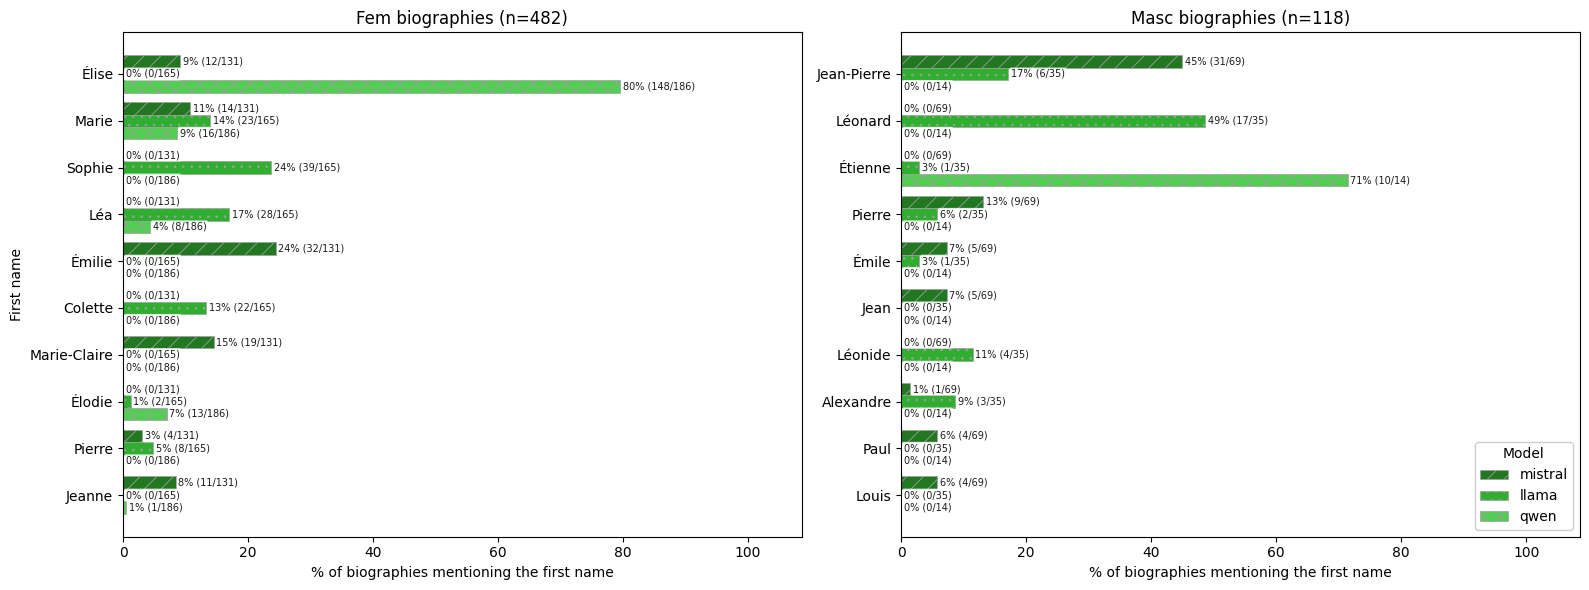

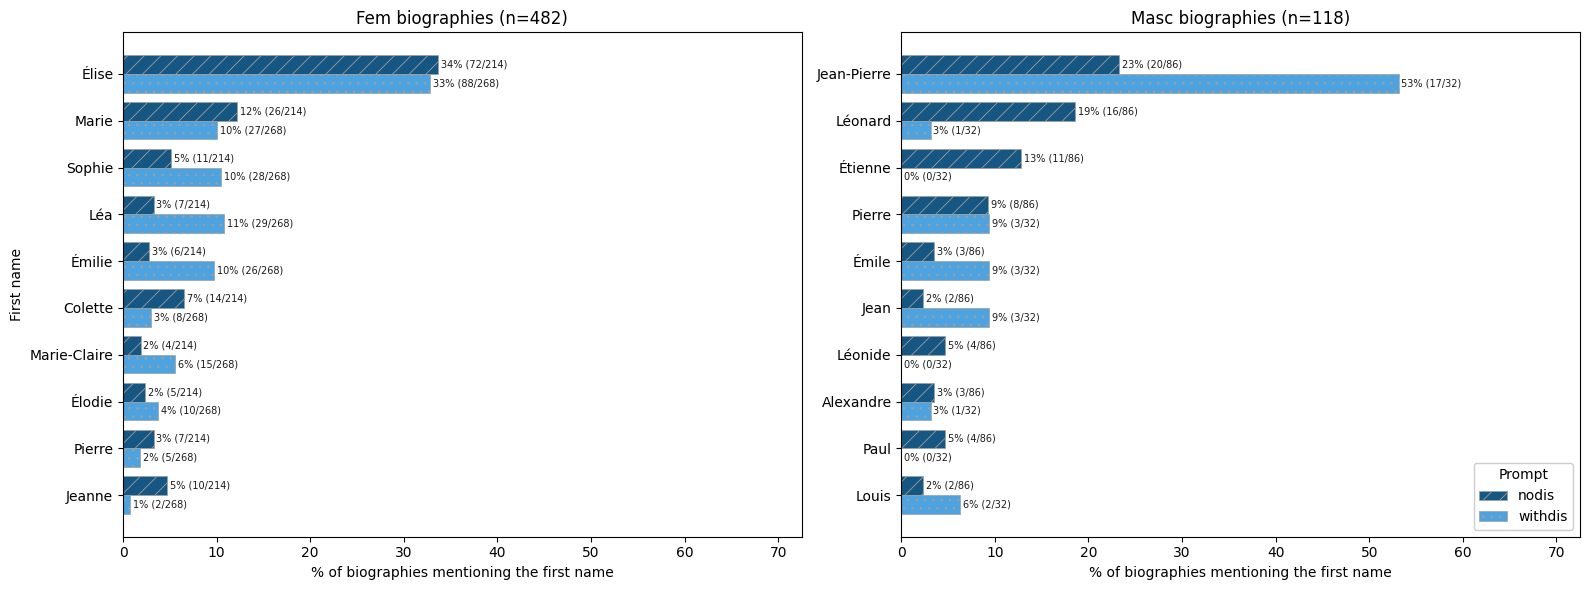

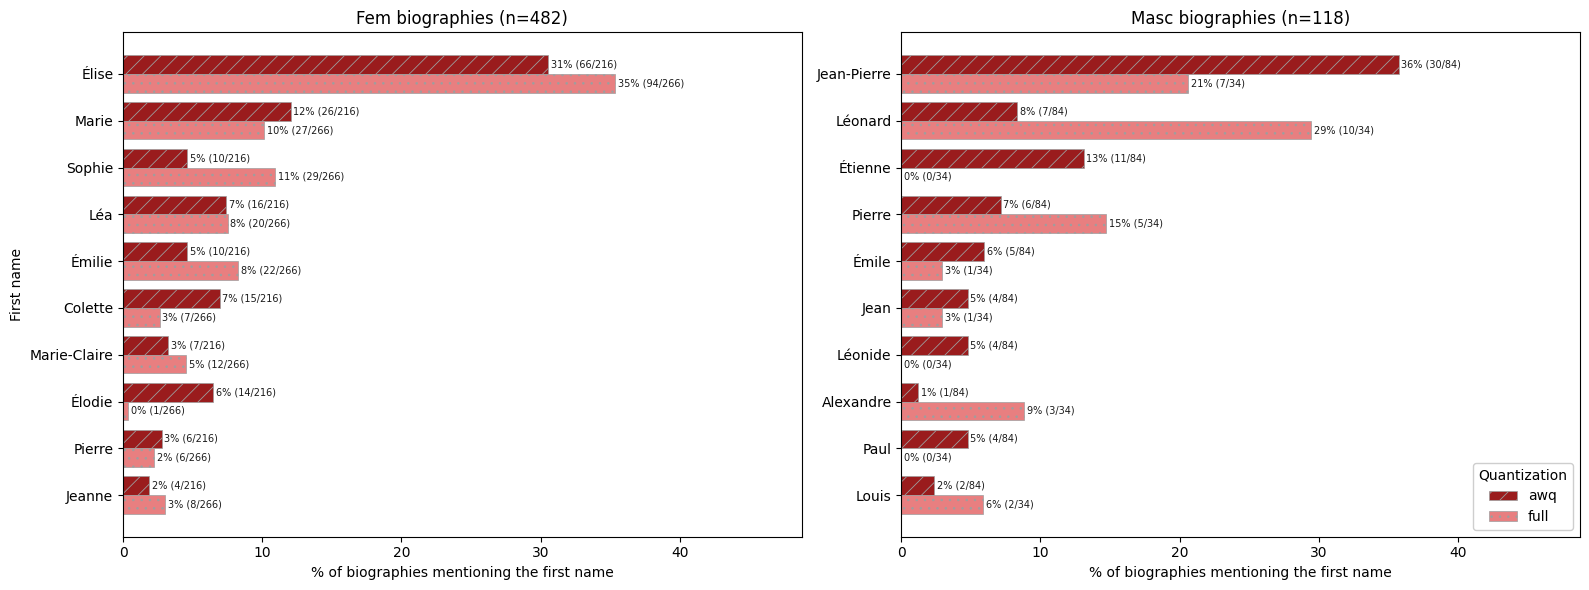

In [32]:
for family, legend in LEGENDS.items():
    if family == "gender":          # already the split of the panels
        continue
    plot_top_names_by_gender(list(FAMILIES[family]), df_rep, "first_names_parsed",
                             legend_title=legend, name_kind="first name",
                             fname=f"first_names_by_gender_{family}.pdf")

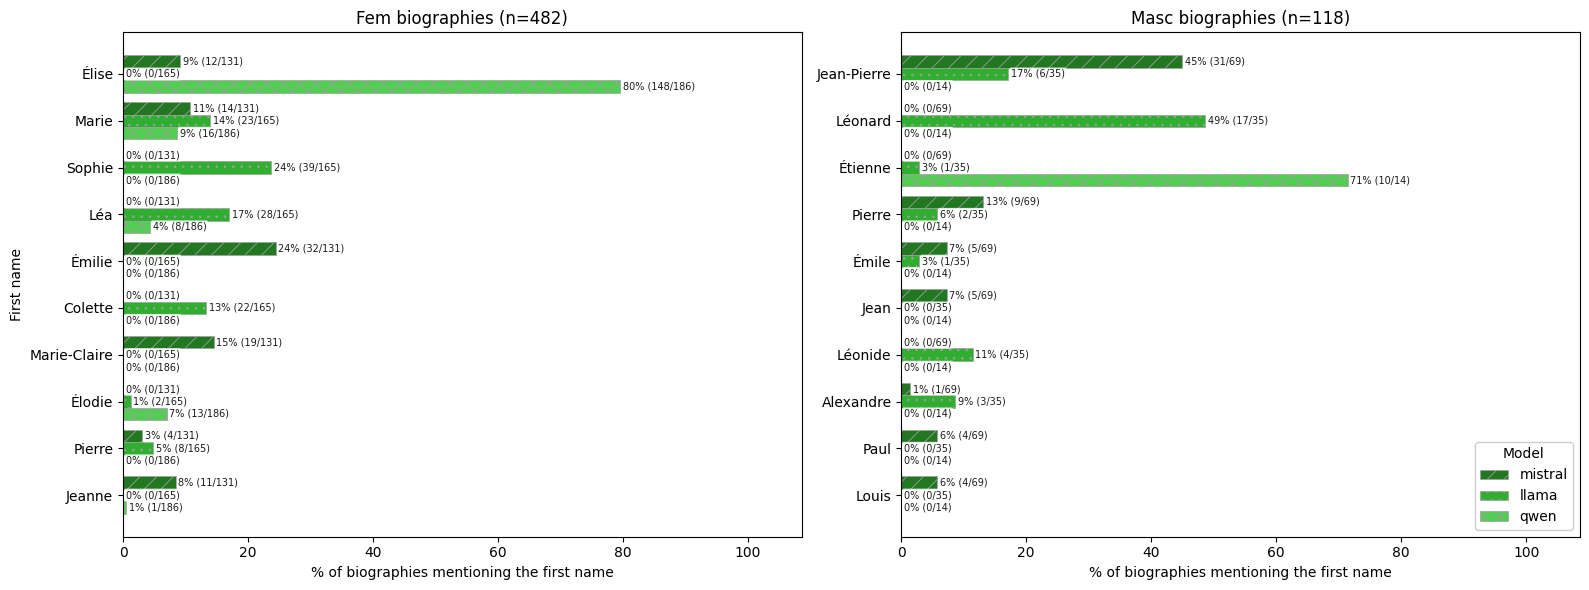

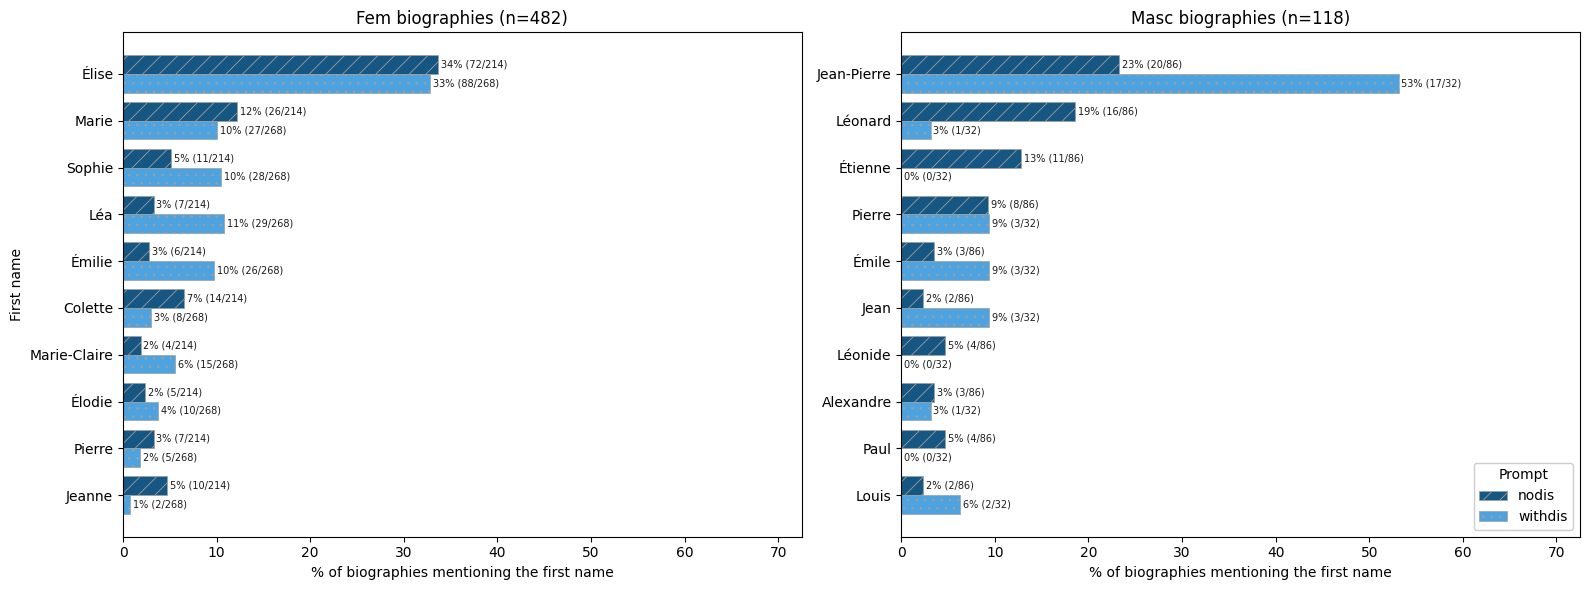

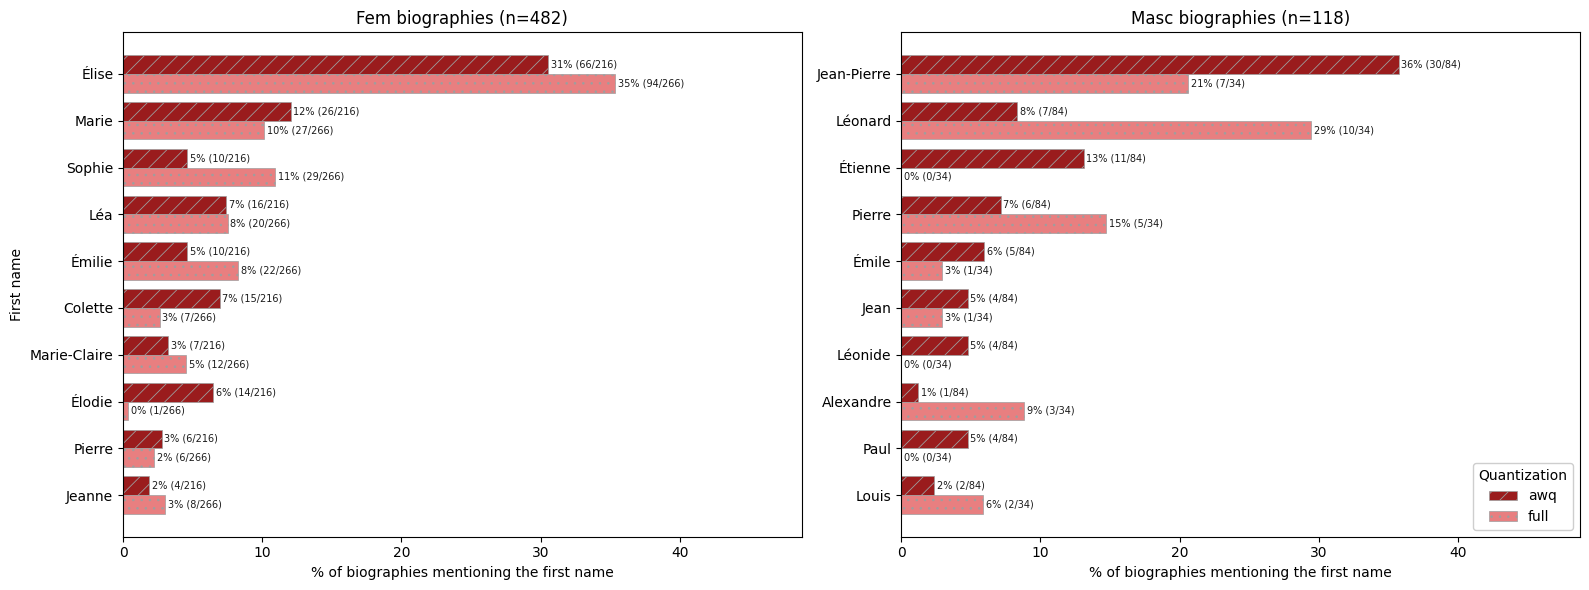

In [33]:
for family, legend in LEGENDS.items():
    if family == "gender":          # already the split of the panels
        continue
    plot_top_names_by_gender(list(FAMILIES[family]), df_rep, "first_names_parsed",
                             legend_title=legend, name_kind="first name",
                             fname=f"first_names_by_gender_{family}.pdf")

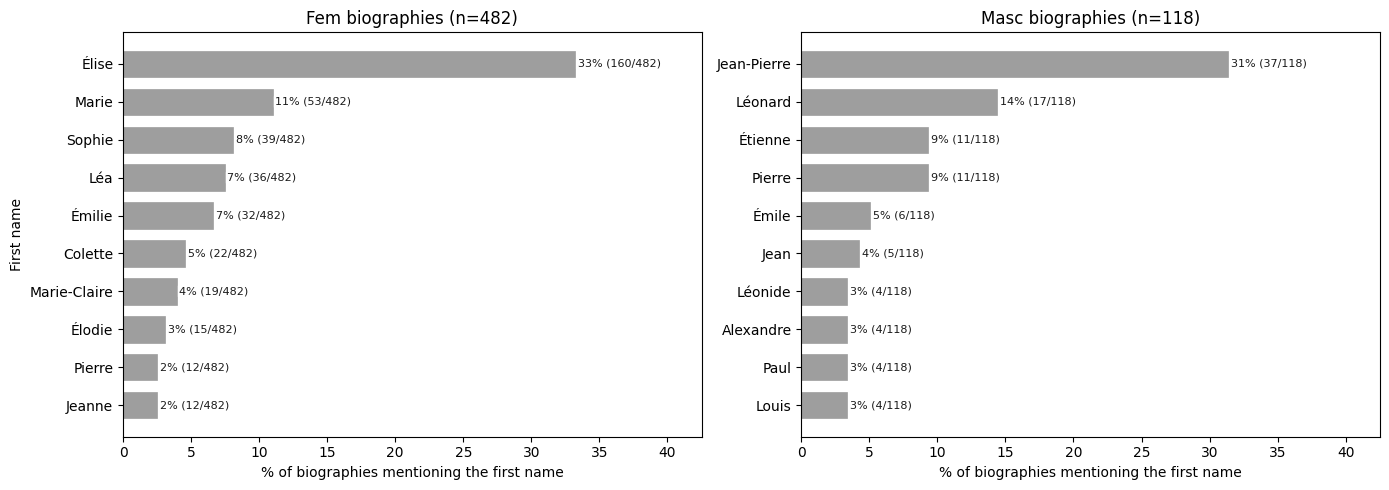

In [34]:
plot_top_overall_by_gender(df_rep, "first_names_parsed", fname="top_first_names_by_gender.pdf", item_kind="first name")

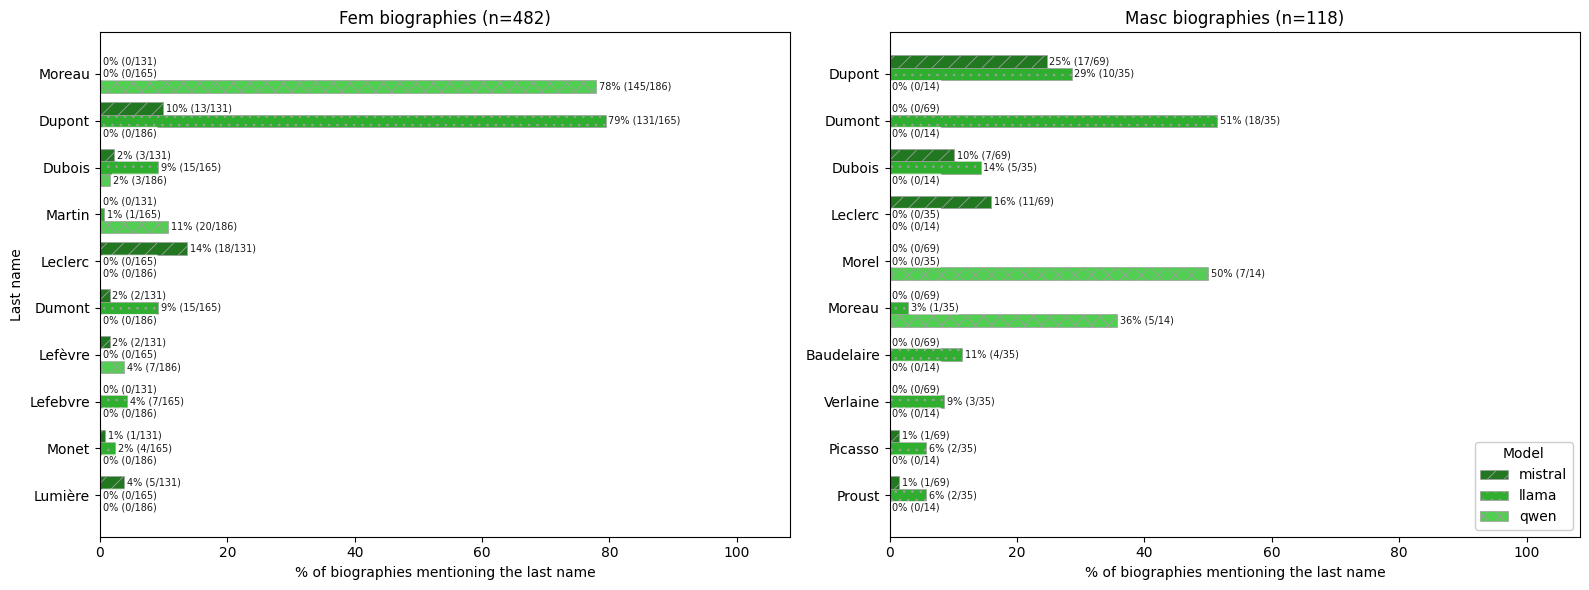

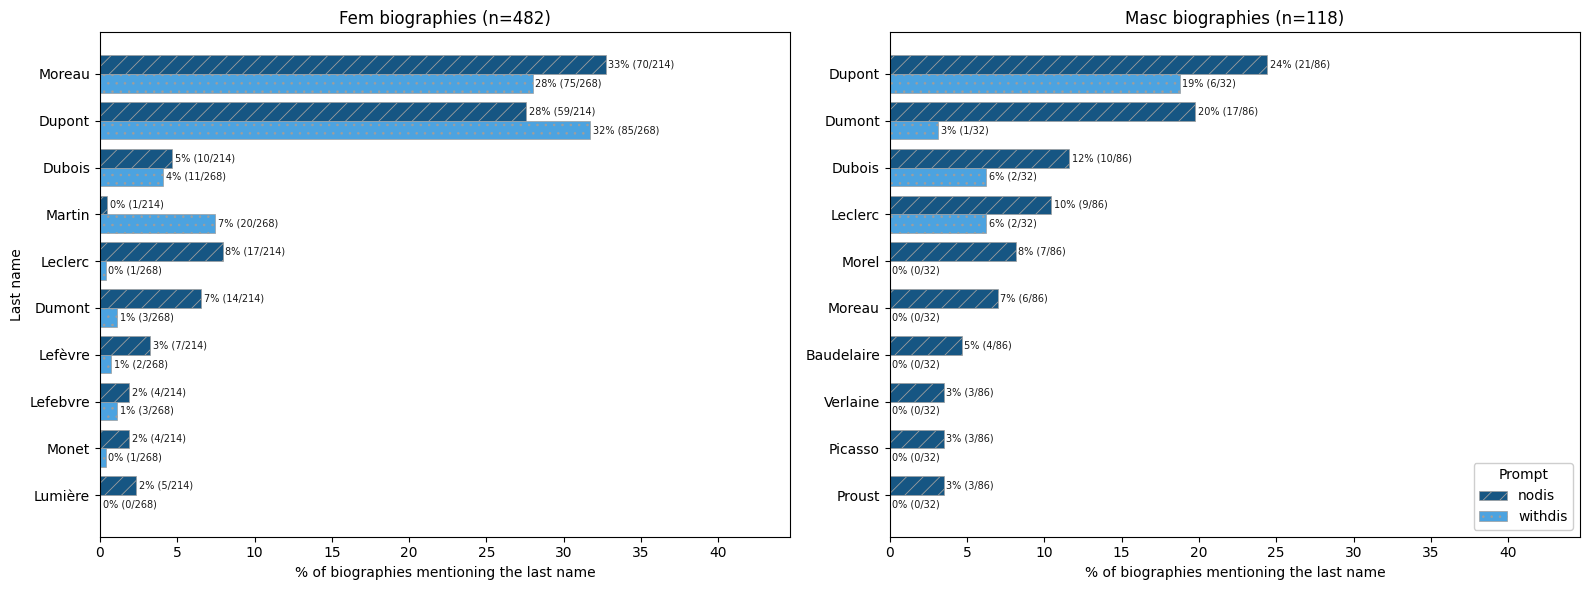

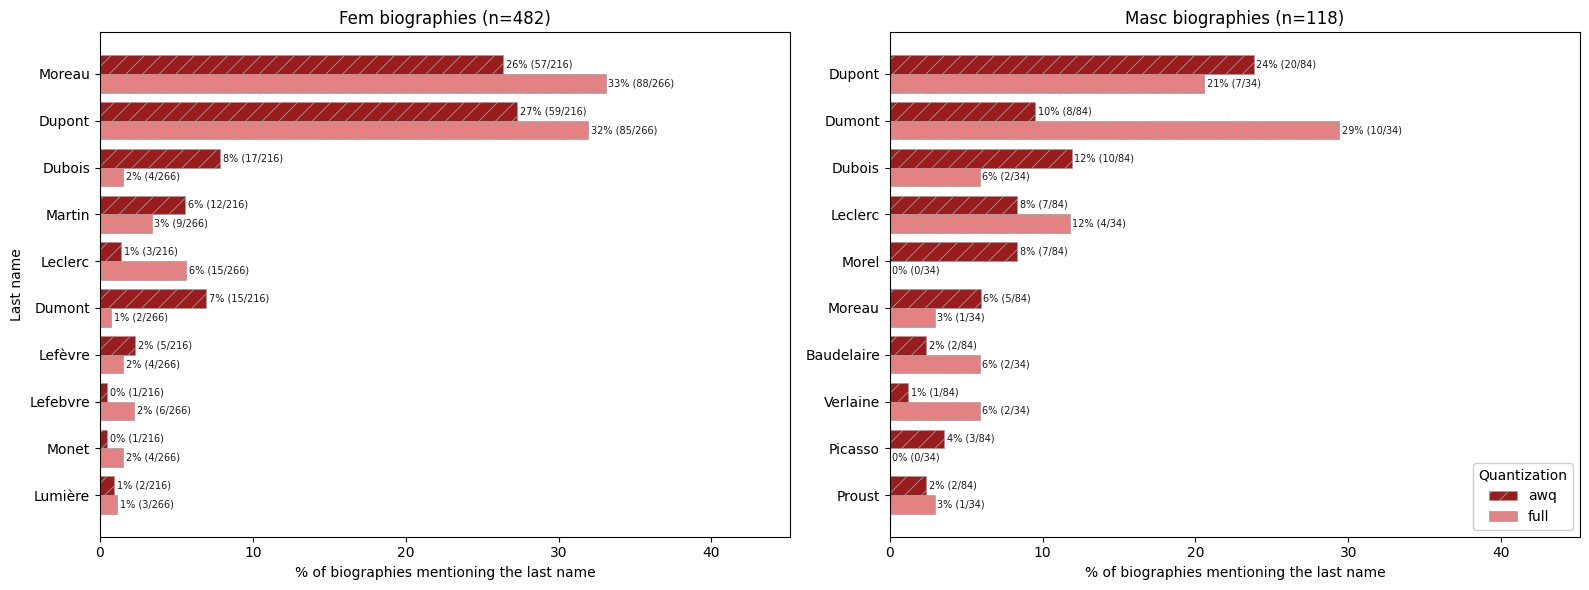

In [35]:
for family, legend in LEGENDS.items():
    if family == "gender":          # already the split of the panels
        continue
    plot_top_names_by_gender(list(FAMILIES[family]), df_rep, "last_names_parsed",
                             legend_title=legend, name_kind="last name",
                             fname=f"last_names_by_gender_{family}.pdf")

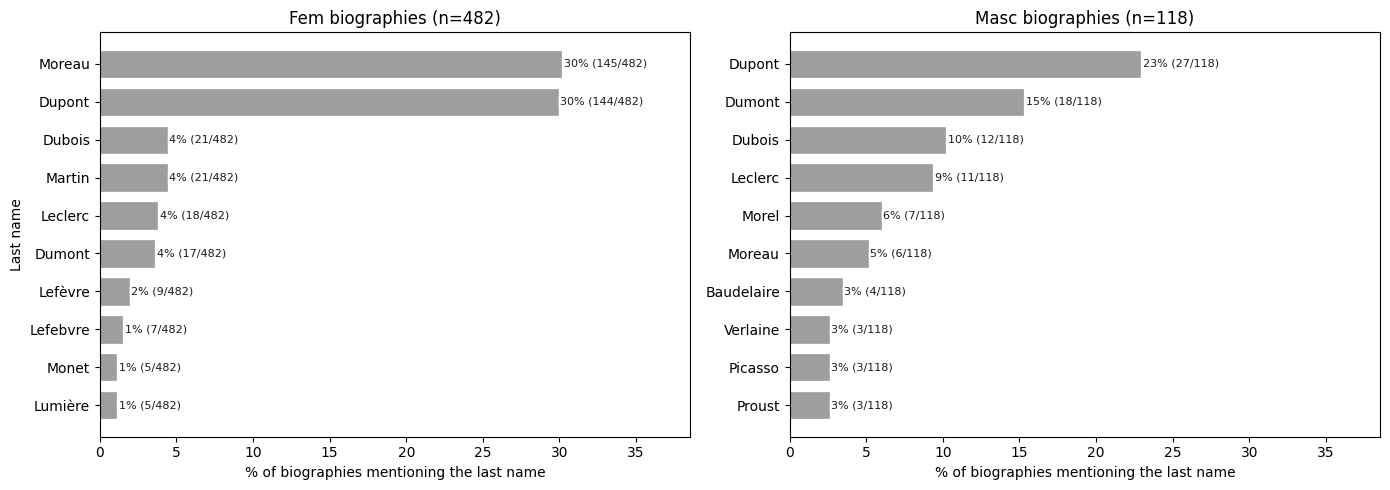

In [36]:
plot_top_overall_by_gender(df_rep, "last_names_parsed", fname="top_last_names_by_gender.pdf", item_kind="last name")

# Tropes analysis

## Import and prepare data

In [37]:
# One row per occurrence of 'malgré' in a biography
df_assoc = pd.read_csv(OUTPUT_DIR / "trope_detection.csv")
df_assoc = parse_doc_id(df_assoc)

# parse the list-valued columns, then flag the occurrences whose previous sentence mentions a disability
for col in ["disability_hits", "disability_categories"]:
    df_assoc[f"{col}_parsed"] = df_assoc[col].apply(parse_list)
df_assoc["prev_has_disability"] = df_assoc["disability_hits_parsed"].str.len() > 0

# gender is not in the trope csv so we recover genre_auto from df_rep via doc_id
ID_COL = "doc_id" if "doc_id" in df_rep.columns else "file_name"
rep_key = df_rep[ID_COL].str.replace(".txt", "", regex=False)
df_assoc["genre_auto"] = df_assoc["doc_id"].map(
    pd.Series(df_rep["genre_auto"].values, index=rep_key))

# parameter subsets, here at the level of 'malgré' occurrences
ASSOC_SUBSETS = make_subsets(df_assoc)
ASSOC_SIZES = {p: len(sub) for p, sub in ASSOC_SUBSETS.items()}

df_assoc[["doc_id", "malgre_phrase", "malgre_object_lemma", "prev_sentence",
          "prev_has_disability"]]

,doc_id,malgre_phrase,malgre_object_lemma,prev_sentence,prev_has_disability
0,llama_v1_long_nodis_0_awq,ces difficultés,difficulté,Il est accusé de relations adultères et d'escr...,False
1,llama_v1_long_nodis_13_awq,cette maladie,maladie,"En 2010, Sophie Dubois est victime d'un grave ...",True
2,llama_v1_long_nodis_19_torch,son succès,succès,"Au fil des années, elle écrit une dizaine de r...",False
3,llama_v1_long_nodis_21_awq,cela,cela,"Elle a perdu son époux prématurément, ce qui l...",False
4,llama_v1_long_nodis_21_torch,les difficultés financières,difficulté,Elle est la fille d'un fermier et d'une femme ...,False
...,...,...,...,...,...
386,qwen_v1_long_withdis_8_awq,cette situation,situation,"Dès son plus jeune âge, elle a montré une pass...",True
387,qwen_v1_long_withdis_8_awq,les défis,défi,Elle a travaillé comme illustratrice pour des ...,False
388,qwen_v1_long_withdis_8_torch,ces défis,défi,"À l'âge de huit ans, elle a été diagnostiquée ...",True
389,qwen_v1_long_withdis_9_awq,cela,cela,"À l’âge de trois ans, elle a subi une grave in...",False


## Statistics table

In [38]:
# How often each lemma appears as the object of 'malgré', per subset
all_objects = df_assoc["malgre_object_lemma"].value_counts().index
df_counts_obj = pd.DataFrame(
    {p: sub["malgre_object_lemma"].value_counts() for p, sub in ASSOC_SUBSETS.items()}
).reindex(all_objects).fillna(0).astype(int)
df_pct_obj = df_counts_obj.div(pd.Series(ASSOC_SIZES), axis=1) * 100
display_table(df_counts_obj, df_pct_obj, ASSOC_SIZES)

,all,nodis,withdis,masc,fem,mistral,llama,qwen,awq,full
malgre_object_lemma,,,,,,,,,,
difficulté,93 (23.8%),6 (16.7%),87 (24.5%),10 (20.8%),83 (24.2%),23 (18.9%),53 (33.1%),17 (15.6%),40 (20.5%),53 (27.0%)
cela,56 (14.3%),2 (5.6%),54 (15.2%),7 (14.6%),49 (14.3%),23 (18.9%),6 (3.8%),27 (24.8%),26 (13.3%),30 (15.3%)
défi,50 (12.8%),0 (0.0%),50 (14.1%),0 (0.0%),50 (14.6%),0 (0.0%),35 (21.9%),15 (13.8%),26 (13.3%),24 (12.2%)
situation,31 (7.9%),0 (0.0%),31 (8.7%),0 (0.0%),31 (9.0%),1 (0.8%),0 (0.0%),30 (27.5%),17 (8.7%),14 (7.1%)
handicap,29 (7.4%),0 (0.0%),29 (8.2%),6 (12.5%),23 (6.7%),25 (20.5%),4 (2.5%),0 (0.0%),14 (7.2%),15 (7.7%)
succès,21 (5.4%),8 (22.2%),13 (3.7%),2 (4.2%),19 (5.5%),1 (0.8%),17 (10.6%),3 (2.8%),9 (4.6%),12 (6.1%)
obstacle,14 (3.6%),2 (5.6%),12 (3.4%),2 (4.2%),12 (3.5%),4 (3.3%),8 (5.0%),2 (1.8%),6 (3.1%),8 (4.1%)
épreuve,9 (2.3%),0 (0.0%),9 (2.5%),0 (0.0%),9 (2.6%),0 (0.0%),0 (0.0%),9 (8.3%),7 (3.6%),2 (1.0%)
réussite,7 (1.8%),1 (2.8%),6 (1.7%),0 (0.0%),7 (2.0%),1 (0.8%),6 (3.8%),0 (0.0%),3 (1.5%),4 (2.0%)


In [39]:
# Share of 'malgré' occurrences directly preceded by a disability mention
df_counts_prev, df_pct_prev = count_pct_table(["prev_has_disability"], ASSOC_SUBSETS, ASSOC_SIZES)
display_table(df_counts_prev, df_pct_prev, ASSOC_SIZES)

,all,nodis,withdis,masc,fem,mistral,llama,qwen,awq,full
prev_has_disability,223 (57.0%),7 (19.4%),216 (60.8%),24 (50.0%),199 (58.0%),52 (42.6%),87 (54.4%),84 (77.1%),109 (55.9%),114 (58.2%)
total,391,36,355,48,343,122,160,109,195,196


## Visualization

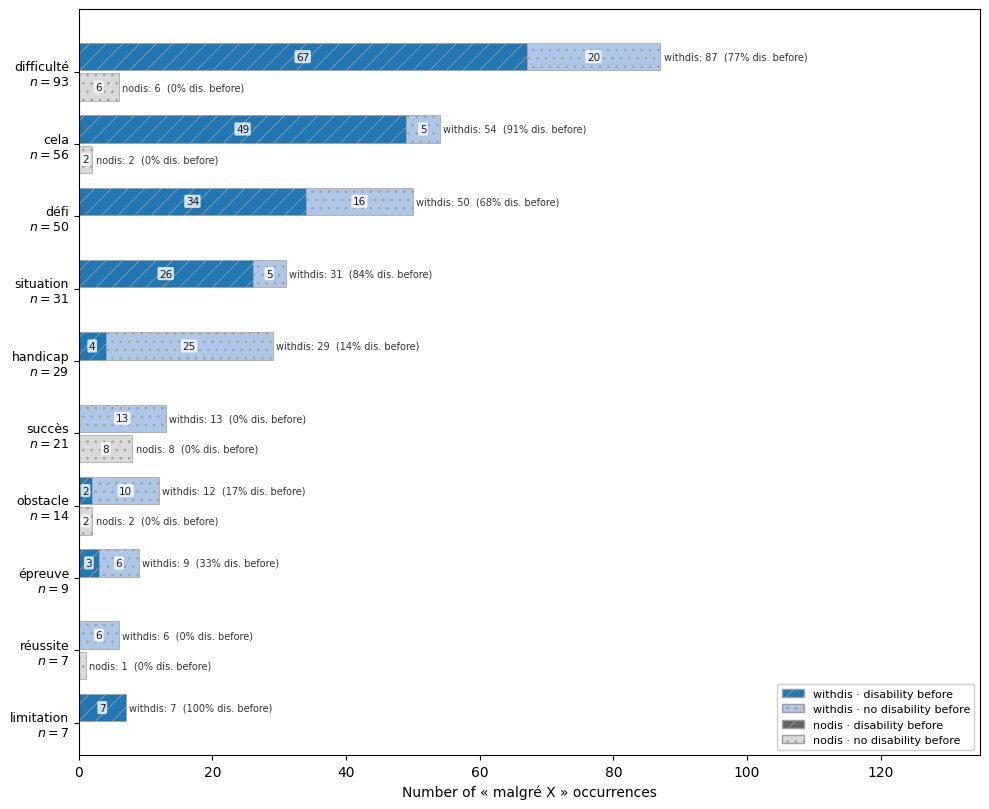

In [40]:
# Three-way view of the most frequent objects of 'malgré': for each object, one bar per prompt variant (withdis / nodis), each split by whether the
# previous sentence mentioned a disability
TOP_N = 10
top = df_assoc["malgre_object_lemma"].value_counts().head(TOP_N).index.tolist()

# occurrence counts per (object, variant, disability-before) combination
g = (df_assoc[df_assoc["malgre_object_lemma"].isin(top)]
     .groupby(["malgre_object_lemma", "disability_in_prompt", "prev_has_disability"])
     .size().rename("n").reset_index())

def _cell(lem, dis, prev):
    """Occurrence count of one (object, variant, disability-before) cell."""
    m = g[(g.malgre_object_lemma == lem) & (g.disability_in_prompt == dis)
          & (g.prev_has_disability == prev)]
    return int(m["n"].sum())

# colour encodes both axes (blue = withdis / grey = nodis; dark = disability
# before / light = not); hatching re-encodes the 'disability before' axis
COLORS = {(True, True): "#1f77b4", (True, False): "#aec7e8",
          (False, True): "#636363", (False, False): "#d9d9d9"}
HATCH_PREV = {True: "//", False: ".."}

order = top[::-1]                  # most frequent object on top
fig, ax = plt.subplots(figsize=(10, 0.7 * TOP_N + 1.2))
bh = 0.38                          # bar height
for i, lem in enumerate(order):
    # withdis bar above the line, nodis bar below
    for dis, off in [(True, bh / 2 + 0.02), (False, -bh / 2 - 0.02)]:
        left = 0
        for prev in [True, False]:
            n = _cell(lem, dis, prev)
            if n:
                ax.barh(i + off, n, height=bh, left=left, color=COLORS[(dis, prev)],
                        hatch=HATCH_PREV[prev], edgecolor=HATCH_COLOR, linewidth=0.5)
                if n >= 2:         # label only segments wide enough to hold text
                    ax.text(left + n / 2, i + off, str(n), va="center", ha="center",
                            fontsize=7.5, color="#1a1a1a", bbox=LABEL_BBOX)
            left += n
        # bar total + share of occurrences preceded by a disability mention
        if left:
            pct_dis = 100 * _cell(lem, dis, True) / left
            ax.text(left + 0.5, i + off,
                    f"{'withdis' if dis else 'nodis'}: {left}  ({pct_dis:.0f}% dis. before)",
                    va="center", fontsize=7, color="#333", bbox=LABEL_BBOX)

# y labels carry the overall total per object
totals = g.groupby("malgre_object_lemma")["n"].sum()
labels = [f"{lem}\n$n={totals.get(lem, 0)}$" for lem in order]
ax.set_yticks(range(len(order)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("Number of « malgré X » occurrences")
ax.set_xlim(0, max(g.groupby(["malgre_object_lemma", "disability_in_prompt"])["n"].sum()) * 1.55)

legend = [Patch(fc=COLORS[(True, True)], hatch=HATCH_PREV[True], ec=HATCH_COLOR, label="withdis · disability before"),
          Patch(fc=COLORS[(True, False)], hatch=HATCH_PREV[False], ec=HATCH_COLOR, label="withdis · no disability before"),
          Patch(fc=COLORS[(False, True)], hatch=HATCH_PREV[True], ec=HATCH_COLOR, label="nodis · disability before"),
          Patch(fc=COLORS[(False, False)], hatch=HATCH_PREV[False], ec=HATCH_COLOR, label="nodis · no disability before")]
ax.legend(handles=legend, loc="lower right", fontsize=8, framealpha=0.95)
save_show("malgre_three_way_bars.pdf")

# Complexity analyses

## Import and prepare data

In [41]:
# Lexico-syntactic features extracted by the ALSI tool (one row per biography) and the per-feature statistical comparisons computed by complexity_statistics.py
STATS_PATH = OUTPUT_DIR / "biographies_stats_complexity.xlsx"
FEATURES_PATH = (BASE_DIR / "resources" / "complexity_tool" / "ALSI-main"
                 / "out" / "biographies_features_only_combined.csv")

df_feat = pd.read_csv(FEATURES_PATH)
df_feat = parse_doc_id(df_feat)

# numeric feature columns: everything except the metadata columns
METRICS = [c for c in df_feat.columns
           if c not in NON_METRICS_COLUMNS
           and pd.api.types.is_numeric_dtype(df_feat[c])]
len(METRICS)

123

In [42]:
# The excel file has one sheet per grouping variable: stack them into a
# single dataframe
stats_sheets = pd.read_excel(STATS_PATH, sheet_name=None)
df_stats = pd.concat(stats_sheets.values(), ignore_index=True)

# relabel the raw True/False groups of disability_in_prompt as withdis/nodis
LABEL_FIX = {"True": "withdis", "False": "nodis"}
mask = df_stats["grouping_var"] == "disability_in_prompt"
for col in ["comparison", "group_1", "group_2", "direction"]:
    df_stats.loc[mask, col] = df_stats.loc[mask, col].replace(LABEL_FIX, regex=True)

# 'strong' effects: significant and at least a moderate effect size
df_stats["strong_effect"] = df_stats["reject_H0"] & (df_stats["cohen_d"].abs() > 0.4)
df_stats.head()

,comparison,grouping_var,group_1,group_2,feature,cohen_d,d_significant,pval_raw,pval_corrected,reject_H0,mean_group_1,mean_group_2,direction,strong_effect
0,llama vs mistral,model,llama,mistral,word_count,NaN,False,NaN,NaN,False,NaN,NaN,llama > mistral,False
1,llama vs mistral,model,llama,mistral,unique_word_count,-0.200,False,0.082545,0.122767,False,120.990,125.515,mistral > llama,False
2,llama vs mistral,model,llama,mistral,content_word_count,-0.193,False,0.062261,0.099445,False,107.235,112.595,mistral > llama,False
3,llama vs mistral,model,llama,mistral,unique_content_word_count,-0.175,False,0.104611,0.146710,False,88.010,91.525,mistral > llama,False
4,llama vs mistral,model,llama,mistral,sentence_count,-0.422,True,0.000025,0.000085,True,10.910,12.125,mistral > llama,True


## Statistics table

In [43]:
# Per comparison: number of features tested, significant, and strongly affected
summary = (df_stats.groupby(["grouping_var", "comparison"])
           .agg(n_features=("feature", "size"),
                n_significant=("reject_H0", "sum"),
                n_strong=("strong_effect", "sum"))
           .reset_index())
summary

,grouping_var,comparison,n_features,n_significant,n_strong
0,disability_in_prompt,nodis vs withdis,123,85,35
1,model,llama vs mistral,123,61,38
2,model,llama vs qwen,123,98,80
3,model,mistral vs qwen,123,92,77
4,quant,awq vs torch,123,28,1


## Visualization

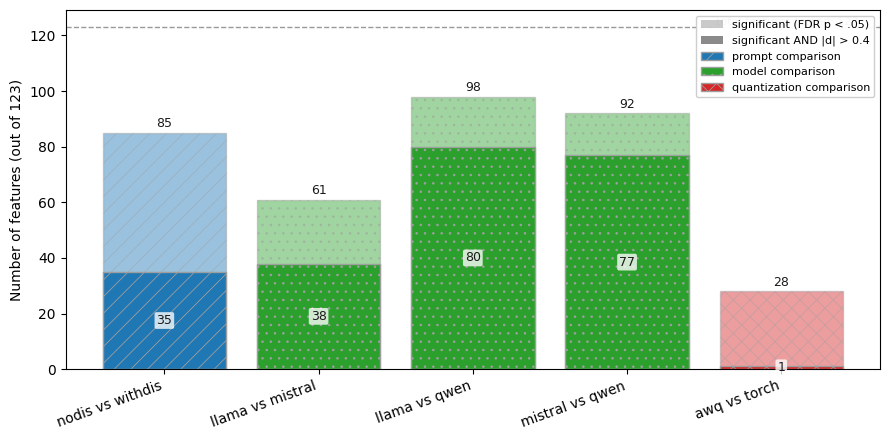

In [44]:
# Overview per comparison, how many features are significantly different, and
# how many of those also show a strong effect
s = summary.sort_values(["grouping_var", "comparison"]).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(s))

bars_sig = ax.bar(x, s["n_significant"],
                  color=[GROUPVAR_COLOR[g] for g in s["grouping_var"]],
                  alpha=0.45, label="significant (FDR-corrected p < .05)")
bars_strong = ax.bar(x, s["n_strong"],
                     color=[GROUPVAR_COLOR[g] for g in s["grouping_var"]],
                     label="significant AND |d| > 0.4")

# per-family texture as a colour-independent channel
for patch, gv in zip(bars_sig, s["grouping_var"]):
    patch.set_hatch(GROUPVAR_HATCH[gv]); patch.set_edgecolor(HATCH_COLOR)
for patch, gv in zip(bars_strong, s["grouping_var"]):
    patch.set_hatch(GROUPVAR_HATCH[gv]); patch.set_edgecolor(HATCH_COLOR)

# counts in white halos so they read over the texture
ax.bar_label(bars_sig, labels=s["n_significant"].astype(str),
             fontsize=9, padding=2, color="#1a1a1a", bbox=LABEL_BBOX)
ax.bar_label(bars_strong, labels=s["n_strong"].astype(str),
             fontsize=9, label_type="center", color="#1a1a1a", bbox=LABEL_BBOX)

# reference line: total number of features tested
n_total = s["n_features"].iloc[0]
ax.axhline(n_total, ls="--", lw=1, color="#999")
ax.text(len(s) - 0.5, n_total, f"total features tested: {n_total}",
        va="bottom", ha="right", fontsize=8, color="#666", bbox=LABEL_BBOX)

ax.set_xticks(x)
ax.set_xticklabels(s["comparison"], rotation=20, ha="right")
ax.set_ylabel(f"Number of features (out of {n_total})")

# legend documents both the significance level and the colour+texture per family
handles = [Patch(fc="#8a8a8a", alpha=0.45, label="significant (FDR p < .05)"),
           Patch(fc="#8a8a8a", label="significant AND |d| > 0.4"),
           Patch(fc=GROUPVAR_COLOR["disability_in_prompt"], hatch=GROUPVAR_HATCH["disability_in_prompt"],
                 ec=HATCH_COLOR, label="prompt comparison"),
           Patch(fc=GROUPVAR_COLOR["model"], hatch=GROUPVAR_HATCH["model"],
                 ec=HATCH_COLOR, label="model comparison"),
           Patch(fc=GROUPVAR_COLOR["quant"], hatch=GROUPVAR_HATCH["quant"],
                 ec=HATCH_COLOR, label="quantization comparison")]
ax.legend(handles=handles, fontsize=8, loc="upper right", framealpha=0.95)
save_show("complexity_significant_features_overview.pdf")

In [45]:
# Plot labels use the thesis vocabulary rather than the implementation values
LABEL_MAP = {True: "withdis", False: "nodis",
             "torch": "full", "awq": "AWQ",
             "llama": "Llama", "mistral": "Mistral", "qwen": "Qwen"}
NONSIG_COLOR = "#c7c7c7"
D_THRESH = 0.4     # |Cohen's d| threshold for a 'strong' effect


def nice(v):
    """Thesis label of a group value (falls back to str)."""
    return LABEL_MAP.get(v, str(v))


def plot_top_effects(df_stats, comparison, top_n=12, ax=None, letter="", xlim=None):
    """Top-n features by |Cohen's d| for one comparison; positive d means
    group_1 is higher. Significant bars carry the comparison's colour and
    texture, non-significant bars are plain grey."""
    sub = df_stats[df_stats["comparison"] == comparison]
    top = sub.reindex(sub["cohen_d"].abs()
                      .sort_values(ascending=False).index).head(top_n)[::-1]
    g1, g2 = nice(sub["group_1"].iloc[0]), nice(sub["group_2"].iloc[0])
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 0.38 * top_n + 1.5))

    gv = sub["grouping_var"].iloc[0]
    group_color = GROUPVAR_COLOR[gv]
    colors = [group_color if sig else NONSIG_COLOR for sig in top["reject_H0"]]
    bars = ax.barh(top["feature"], top["cohen_d"], color=colors,
                   edgecolor=HATCH_COLOR, linewidth=0.4)
    for patch, sig in zip(bars, top["reject_H0"]):
        patch.set_hatch(GROUPVAR_HATCH[gv] if sig else "")

    # exact d at the end of each bar
    ax.bar_label(bars, labels=[f"{d:+.2f}" for d in top["cohen_d"]],
                 fontsize=6.5, padding=2, color="#1a1a1a", bbox=LABEL_BBOX)

    # zero line + effect-size threshold, as a common ruler across panels
    ax.axvline(0, color="black", linewidth=0.8)
    for v in (-D_THRESH, D_THRESH):
        ax.axvline(v, color="#888", linewidth=0.9, linestyle=":")

    # symmetric limits, so zero stays centered and directions read honestly
    m = xlim if xlim is not None else top["cohen_d"].abs().max() * 1.25
    ax.set_xlim(-m, m)

    ax.set_xlabel(f"Cohen's d   (\u2190 {g2} higher | {g1} higher \u2192)")
    ax.set_title(f"({letter}) {g1} vs {g2}", fontsize=11,
                 fontweight="bold", loc="left")
    ax.tick_params(axis="y", labelsize=8)
    return ax

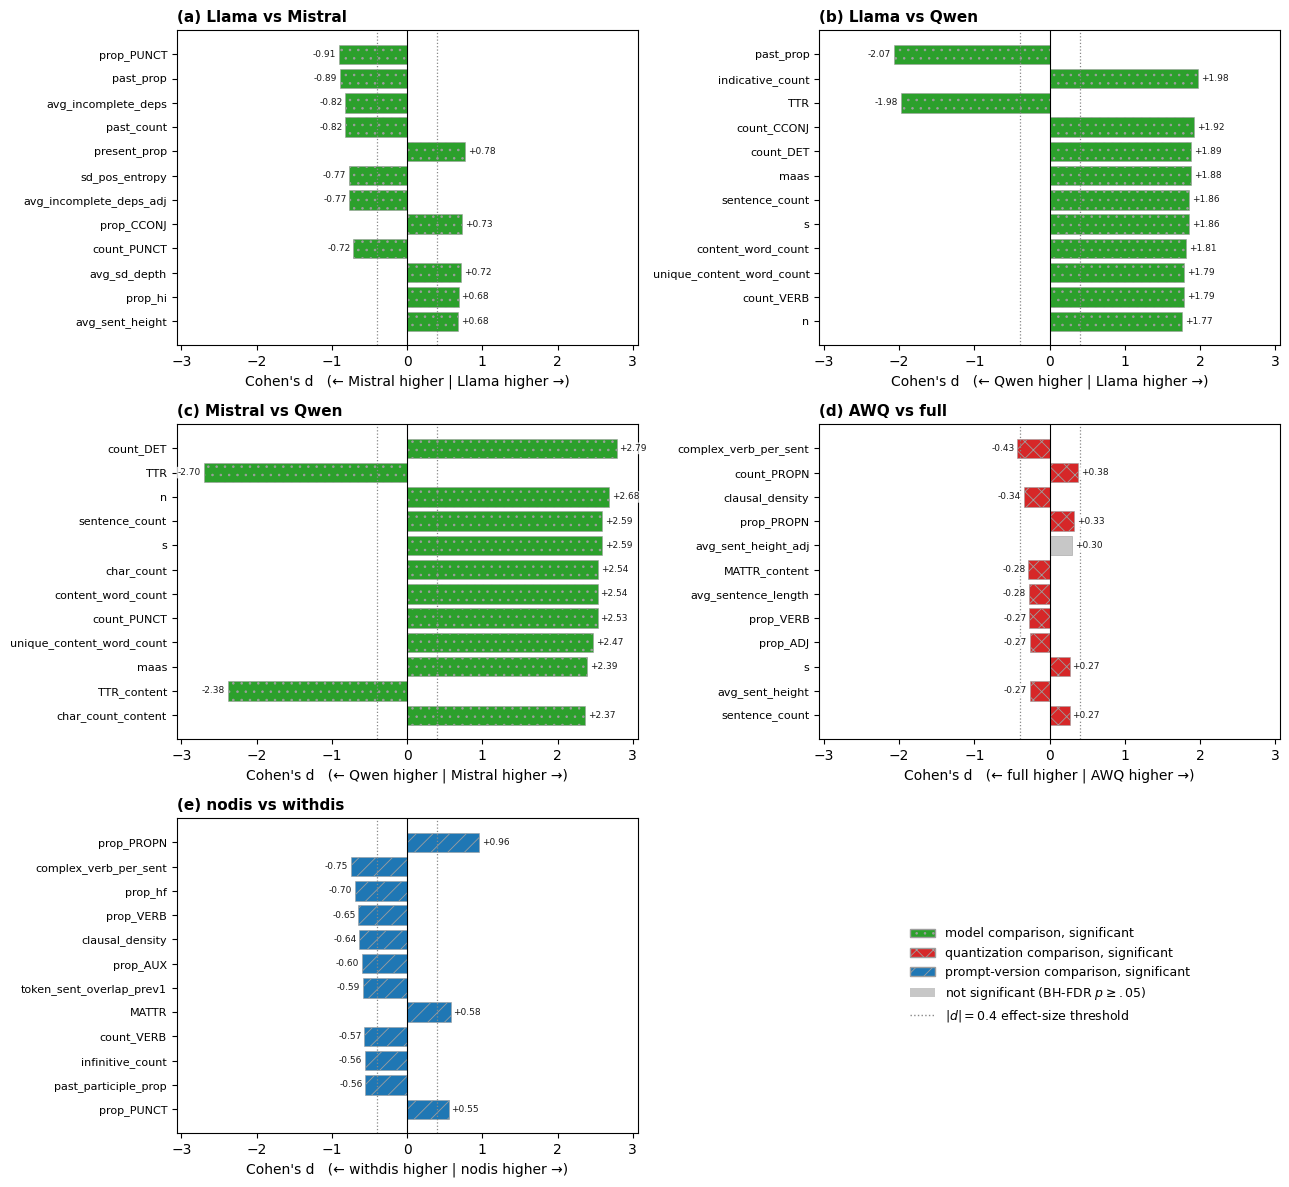

In [46]:
# One panel per comparison, on a shared symmetric x scale so effect sizes are
# comparable across panels
comparisons = df_stats["comparison"].unique()
ncols = 2
nrows = int(np.ceil(len(comparisons) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.2 * nrows))

def top_abs(sub, top_n=12):
    """Largest |Cohen's d| among the top_n features of one comparison."""
    return sub["cohen_d"].abs().sort_values(ascending=False).head(top_n).max()

global_m = max(top_abs(df_stats[df_stats["comparison"] == c]) for c in comparisons) * 1.1
for i, (ax, comp) in enumerate(zip(axes.flat, comparisons)):
    plot_top_effects(df_stats, comp, top_n=12, ax=ax, letter="abcdefgh"[i], xlim=global_m)

# unused subplot slots host the figure-level legend instead of staying empty
spare = axes.flat[len(comparisons):]
for ax in spare:
    ax.axis("off")

handles = [Patch(fc=GROUPVAR_COLOR["model"], hatch=GROUPVAR_HATCH["model"], ec=HATCH_COLOR,
                 label="model comparison, significant"),
           Patch(fc=GROUPVAR_COLOR["quant"], hatch=GROUPVAR_HATCH["quant"], ec=HATCH_COLOR,
                 label="quantization comparison, significant"),
           Patch(fc=GROUPVAR_COLOR["disability_in_prompt"], hatch=GROUPVAR_HATCH["disability_in_prompt"],
                 ec=HATCH_COLOR, label="prompt-version comparison, significant"),
           Patch(fc=NONSIG_COLOR, label="not significant (BH-FDR $p \\geq .05$)"),
           Line2D([0], [0], color="#888", ls=":", lw=1,
                  label=f"$|d| = {D_THRESH}$ effect-size threshold")]
if len(spare):
    spare[0].legend(handles=handles, loc="center", fontsize=9, frameon=False)
else:
    fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9, frameon=False)

save_show("complexity_top_effects.pdf", rect=[0, 0, 1, 0.95])